# Model Ablation Comparison (Clean Rewrite)

This notebook evaluates selected Uniform/Zonal ablations with consistent model filtering (excluding `Full`) and emphasizes raw-life error metrics for `LogLife`.


In [22]:
from __future__ import annotations

import ast
import contextlib
import importlib.util
import os
import sys
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from IPython.display import Markdown, display

try:
    import torch
except Exception:
    torch = None

try:
    import h5py
except Exception:
    h5py = None

try:
    from sklearn.model_selection import train_test_split
except Exception:
    train_test_split = None

pd.set_option('display.max_colwidth', 160)


In [23]:
# Global config (defined once)
CURRENT_DIR = Path(os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd())
REPO_ROOT = CURRENT_DIR if (CURRENT_DIR / 'Uniform').exists() else CURRENT_DIR.parent
CHECKPOINT_ROOT = REPO_ROOT
H5_DATASET_ROOT = REPO_ROOT / 'Data_gen' / 'output'
SPLIT_SEED = 42
SPLIT_SIZE = 0.2

import sys as _sys
if str(CURRENT_DIR) not in _sys.path:
    _sys.path.insert(0, str(CURRENT_DIR))
import eval_helpers as eh

OUTPUT_DIR = CURRENT_DIR / 'eval_outputs'
FIGURES_DIR = CURRENT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

EXAMPLE_DIR_CANDIDATES = [
    Path('/home/runner/Desktop/Disc_lifing_paper/Comparison/Examples'),
    Path('/Desktop/Disc_lifing_paper/Comparison/Examples'),
    REPO_ROOT / 'Comparison' / 'Examples',
]

# PointNetMLPJoint_FP only exists for Zonal/Edge today. It is included wherever discovered.
TARGET_FAMILIES = ['ArGEnT_self_att_noSDF', 'PointNetMLPJoint', 'PointNetMLPJoint_headfeat', 'PointNetMLPJoint_FP']
MAIN_FAMILIES = ['ArGEnT_self_att_noSDF', 'PointNetMLPJoint', 'PointNetMLPJoint_FP']
MODEL_COLORS = {
    'ArGEnT_self_att_noSDF': '#1f77b4',
    'PointNetMLPJoint': '#ff7f0e',
    'PointNetMLPJoint_headfeat': '#2ca02c',
    'PointNetMLPJoint_FP': '#d62728',
}

if not (REPO_ROOT / 'Uniform').exists() or not (REPO_ROOT / 'Zonal').exists():
    raise RuntimeError(f'Could not locate repository root from {CURRENT_DIR}')

# Expected EXTRA_FEAT_COLS for PointNetMLPJoint per ablation
# Derived from ArGEnT INPUT_COLS minus [0, 1] (the always-present coordinate dims).
# Used to validate checkpoints and catch ablation bugs early.
EXPECTED_PN_EXTRA_FEAT_COLS: Dict[str, List[int]] = {
    'Edge':           [],
    'Edge_arc':       [3],
    'Edge_arc_feat':  [3, 4, 5, 6, 7],
    'Edge_no_stress': [],
    'Edge_Prox':      [],
    'Edge_zoneID':    [2],
}

# Principal paper-facing comparison: clean Edge inputs under Zonal sampling only.
# EdgeProx / derivative-feature ablations are reported separately (never mixed in).
PRINCIPAL_REGIME = 'Zonal'
PRINCIPAL_ABLATION = 'Edge'


In [24]:
def map_target_name(name: str) -> str:
    s = str(name).strip().lower()
    if 'stress' in s:
        return 'Stress'
    if 'life' in s:
        return 'LogLife'
    return str(name)


def parse_training_constants(training_script: Path) -> Dict[str, Any]:
    if not training_script.exists():
        return {}
    tree = ast.parse(training_script.read_text(encoding='utf-8'))
    wanted = {'TARGET_NAMES', 'INPUT_COLS', 'QUERY_COLS', 'H5_FILENAME'}
    out: Dict[str, Any] = {}
    for node in tree.body:
        if isinstance(node, ast.AnnAssign) and isinstance(node.target, ast.Name) and node.target.id in wanted and node.value is not None:
            try:
                out[node.target.id] = ast.literal_eval(node.value)
            except Exception:
                pass
        elif isinstance(node, ast.Assign):
            for target in node.targets:
                if isinstance(target, ast.Name) and target.id in wanted:
                    try:
                        out[target.id] = ast.literal_eval(node.value)
                    except Exception:
                        pass
    return out


def discover_model_rows() -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    for regime in ['Uniform', 'Zonal']:
        regime_dir = CHECKPOINT_ROOT / regime
        if not regime_dir.exists():
            continue
        for ablation_dir in sorted([p for p in regime_dir.iterdir() if p.is_dir()]):
            ablation = ablation_dir.name
            if ablation.lower() == 'full':
                continue
            for model_dir in sorted([p for p in ablation_dir.iterdir() if p.is_dir()]):
                model_family = model_dir.name
                if model_family not in TARGET_FAMILIES:
                    continue
                ts_path = model_dir / 'Training_script.py'
                cfg = parse_training_constants(ts_path)
                ckpts = sorted((model_dir / 'Trained_models').glob('*.pt')) if (model_dir / 'Trained_models').exists() else []
                rows.append({
                    'regime': regime,
                    'ablation': ablation,
                    'model_family': model_family,
                    'training_dir': model_dir,
                    'training_script': ts_path,
                    'checkpoint_path': ckpts[0] if ckpts else None,
                    'target_names': [map_target_name(t) for t in cfg.get('TARGET_NAMES', [])],
                    'input_cols': cfg.get('INPUT_COLS', [0, 1]),
                    'query_cols': cfg.get('QUERY_COLS', [0, 1]),
                    'h5_filename': cfg.get('H5_FILENAME'),
                })
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.sort_values(['regime', 'ablation', 'model_family']).reset_index(drop=True)


def load_h5_pointsets(path: Path) -> List[Dict[str, Any]]:
    """Return one dict per geometry sample (nodes of one sample never split across sets).

    Each dict has 'arr' (the model-input array, same column layout as before) plus
    'sample_id', 'zone_id', 'subzone_id', 'arc_length_mm' for node-level analysis.
    """
    out: List[Dict[str, Any]] = []
    with h5py.File(path, 'r') as f:
        if 'samples' not in f:
            raise RuntimeError(f"'samples' group missing in {path}")
        for key in sorted(f['samples'].keys()):
            grp = f['samples'][key]
            coords = grp['node_coords_mm'][:].astype(np.float32)
            zone_id = grp['zone_id'][:].astype(np.float32)
            stress = grp['stress_max_vm'][:].astype(np.float32)
            life_raw = grp['life_raw'][:].astype(np.float32)
            cols: List[np.ndarray] = [coords[:, 0], coords[:, 1], zone_id]
            arc_length_mm = None
            if 'arc_length_mm' in grp:
                arc = grp['arc_length_mm'][:].astype(np.float32)
                if not np.any(np.isnan(arc)):
                    cols.append(arc)
                    arc_length_mm = arc
            if 'node_features' in grp:
                feats = grp['node_features'][:]
                if feats.ndim == 2 and feats.shape[1] > 0:
                    for i in range(feats.shape[1]):
                        cols.append(feats[:, i].astype(np.float32))
            cols.append(stress)
            cols.append(np.log10(np.clip(life_raw, 1e-12, None)).astype(np.float32))
            arr = np.stack(cols, axis=-1).astype(np.float32)
            subzone_id = grp['subzone_id'][:].astype(np.float32) if 'subzone_id' in grp else None
            sample_id = int(grp.attrs['sample_id']) if 'sample_id' in grp.attrs else int(key.split('_')[-1])
            out.append({
                'arr': arr, 'sample_id': sample_id, 'zone_id': zone_id,
                'subzone_id': subzone_id, 'arc_length_mm': arc_length_mm,
            })
    return out


def split_indices(n: int, test_size: float = SPLIT_SIZE, random_state: int = SPLIT_SEED) -> Tuple[np.ndarray, np.ndarray]:
    idx = np.arange(n)
    if train_test_split is not None:
        tr, va = train_test_split(idx, test_size=test_size, random_state=random_state)
        return np.asarray(tr, dtype=int), np.asarray(va, dtype=int)
    rng = np.random.default_rng(random_state)
    perm = rng.permutation(idx)
    n_val = max(1, int(round(n * test_size)))
    return perm[n_val:], perm[:n_val]


def mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.mean((y_true - y_pred) ** 2))


def rmse(y_true, y_pred):
    return float(np.sqrt(mse(y_true, y_pred)))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.mean(np.abs(y_true - y_pred)))


def r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    if ss_tot <= 1e-12:
        return np.nan
    return float(1.0 - ss_res / ss_tot)


def loglife_to_raw_life(loglife: np.ndarray) -> np.ndarray:
    x = np.asarray(loglife, dtype=np.float64)
    return np.power(10.0, np.clip(x, -30.0, 30.0))


def percentage_metrics(y_true_raw: np.ndarray, y_pred_raw: np.ndarray) -> Dict[str, float]:
    y_true_raw = np.asarray(y_true_raw, dtype=np.float64)
    y_pred_raw = np.asarray(y_pred_raw, dtype=np.float64)
    denom = np.clip(y_true_raw, 1e-12, None)
    pe = (y_pred_raw - y_true_raw) / denom * 100.0
    ape = np.abs(pe)
    return {
        'MAPE (%)': float(np.mean(ape)),
        'MPE (%)': float(np.mean(pe)),
        'Max_PE (%)': float(np.max(ape)),
    }


# ─────────────────────────────────────────────────────────────────────────────
# Checkpoint integrity audit
# ─────────────────────────────────────────────────────────────────────────────
import hashlib


def compute_checkpoint_sha256(path: Path) -> str:
    """Return hex SHA-256 of the checkpoint file, or empty string on error."""
    try:
        h = hashlib.sha256()
        with open(path, 'rb') as f:
            for chunk in iter(lambda: f.read(1 << 20), b''):
                h.update(chunk)
        return h.hexdigest()
    except Exception:
        return ''


def audit_checkpoint_integrity(rows_df: pd.DataFrame) -> pd.DataFrame:
    """
    For each row with a valid checkpoint:
      1. Compute SHA-256 hash of the checkpoint file.
      2. Detect byte-identical checkpoints across different ablations
         within the same (regime, model_family) group.
      3. For PointNetMLPJoint* models: compare the checkpoint's
         extra_feat_cols against EXPECTED_PN_EXTRA_FEAT_COLS.

    Returns an audit DataFrame with columns:
      regime, ablation, model_family, checkpoint_path,
      sha256, file_bytes,
      duplicate_of (list of other ablations sharing this hash, or []),
      extra_feat_cols_ckpt, expected_extra_feat_cols, feat_cols_match
    """
    if rows_df.empty:
        return pd.DataFrame()

    records: List[Dict[str, Any]] = []
    # Pre-compute hashes
    hash_map: Dict[str, List[str]] = {}  # sha256 -> list of (regime/ablation/family)

    for _, row in rows_df.iterrows():
        ckpt = row.get('checkpoint_path')
        if ckpt is None or not Path(ckpt).exists():
            continue
        sha = compute_checkpoint_sha256(Path(ckpt))
        label = f"{row['regime']}/{row['ablation']}/{row['model_family']}"
        hash_map.setdefault(sha, []).append(label)

    issues = []
    for _, row in rows_df.iterrows():
        ckpt = row.get('checkpoint_path')
        rec: Dict[str, Any] = {
            'regime': row['regime'],
            'ablation': row['ablation'],
            'model_family': row['model_family'],
            'checkpoint_path': str(ckpt) if ckpt else None,
            'sha256': '',
            'file_bytes': None,
            'duplicate_of': [],
            'extra_feat_cols_ckpt': None,
            'expected_extra_feat_cols': EXPECTED_PN_EXTRA_FEAT_COLS.get(row['ablation']),
            'feat_cols_match': None,
        }
        if ckpt is None or not Path(ckpt).exists():
            records.append(rec)
            continue

        sha = compute_checkpoint_sha256(Path(ckpt))
        rec['sha256'] = sha
        rec['file_bytes'] = Path(ckpt).stat().st_size

        label = f"{row['regime']}/{row['ablation']}/{row['model_family']}"
        all_sharing = hash_map.get(sha, [])
        rec['duplicate_of'] = [x for x in all_sharing if x != label]

        # Load checkpoint metadata for PN models
        if torch is not None and row['model_family'].startswith('PointNetMLPJoint'):
            try:
                ckpt_data = torch.load(ckpt, map_location='cpu', weights_only=False)
                efc = ckpt_data.get('extra_feat_cols')
                rec['extra_feat_cols_ckpt'] = efc
                expected = EXPECTED_PN_EXTRA_FEAT_COLS.get(row['ablation'])
                if expected is not None and efc is not None:
                    rec['feat_cols_match'] = (list(efc) == list(expected))
                elif expected is None:
                    rec['feat_cols_match'] = None  # unknown ablation
                else:
                    rec['feat_cols_match'] = False  # missing from checkpoint
            except Exception as exc:
                rec['extra_feat_cols_ckpt'] = f'ERROR: {exc}'

        records.append(rec)

    audit_df = pd.DataFrame(records)
    return audit_df


def display_audit_report(audit_df: pd.DataFrame) -> None:
    """Display the integrity audit report and raise on critical failures."""
    if audit_df.empty:
        display(Markdown('**Integrity audit: no checkpoints to audit.**'))
        return

    critical_issues: List[str] = []
    warnings_list: List[str] = []

    for _, row in audit_df.iterrows():
        label = f"{row['regime']}/{row['ablation']}/{row['model_family']}"
        if row['duplicate_of']:
            msg = (
                f"**CRITICAL — DUPLICATE CHECKPOINT**: {label} shares the same "
                f"SHA-256 as: {row['duplicate_of']}. "
                f"These ablations are byte-identical and will produce IDENTICAL metrics."
            )
            critical_issues.append(msg)
        if row['feat_cols_match'] is False:
            msg = (
                f"**CRITICAL — FEATURE MISMATCH**: {label}: checkpoint `extra_feat_cols`={row['extra_feat_cols_ckpt']!r} "
                f"does not match expected {row['expected_extra_feat_cols']!r} for this ablation. "
                f"The model was trained with wrong features and must be retrained."
            )
            critical_issues.append(msg)

    # Show summary table
    display_cols = [
        'regime', 'ablation', 'model_family',
        'sha256', 'file_bytes',
        'duplicate_of', 'extra_feat_cols_ckpt', 'expected_extra_feat_cols', 'feat_cols_match'
    ]
    show_cols = [c for c in display_cols if c in audit_df.columns]
    display(Markdown('### Checkpoint Integrity Audit'))
    display(audit_df[show_cols])

    if critical_issues:
        display(Markdown(
            '\n---\n'
            '## ⚠️  ABLATION COMPARISON IS INVALID \n'
            'The following critical issues were detected. '
            'Results from affected ablations CANNOT be trusted. '
            'The models must be **retrained** with the corrected training scripts before valid comparison is possible.\n\n' +
            '\n\n'.join(f'- {m}' for m in critical_issues)
        ))
    else:
        display(Markdown('✅ No integrity issues detected.'))


def check_prediction_diversity(metrics_df: pd.DataFrame) -> None:
    """Warn if different ablations of the same model family produce identical metrics."""
    if metrics_df.empty:
        return
    metric_cols = ['MSE', 'RMSE', 'MAE', 'R2 (log)']
    cols = [c for c in metric_cols if c in metrics_df.columns]
    if not cols:
        return

    issues = []
    for (regime, model_family, target), grp in metrics_df.groupby(['regime', 'model_family', 'target']):
        if len(grp) < 2:
            continue
        # Round to 8 significant figures to avoid float noise
        rounded = grp[cols].round(8)
        dupes = rounded.duplicated(keep=False)
        if dupes.any():
            dupe_ablations = grp.loc[dupes, 'ablation'].tolist()
            issues.append(
                f"{regime}/{model_family}/{target}: ablations {dupe_ablations} "
                f"produce identical metrics (MSE={grp.loc[dupes, 'MSE'].iloc[0]:.6f})"
            )

    if issues:
        display(Markdown(
            '\n---\n'
            '## ⚠️  IDENTICAL PREDICTIONS DETECTED\n'
            'The following groups have ablations producing byte-identical metrics. '
            'This strongly indicates shared/copied checkpoints.\n\n' +
            '\n'.join(f'- {m}' for m in issues)
        ))
    else:
        display(Markdown('✅ All evaluated ablations produce distinct metrics.'))


In [25]:
@contextlib.contextmanager
def prepend_sys_path(path: Path):
    p = str(path)
    sys.path.insert(0, p)
    try:
        yield
    finally:
        if p in sys.path:
            sys.path.remove(p)


def import_module_from_file(module_name: str, file_path: Path):
    spec = importlib.util.spec_from_file_location(module_name, str(file_path))
    if spec is None or spec.loader is None:
        raise RuntimeError(f'Cannot import {file_path}')
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


def to_numpy(x):
    if torch is not None and isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def denorm_targets(pred_norm: np.ndarray, ckpt: Dict[str, Any], n_targets: int) -> np.ndarray:
    target_mean = to_numpy(ckpt['target_mean']).reshape(1, -1)
    target_std = to_numpy(ckpt['target_std']).reshape(1, -1)
    if target_mean.shape[1] < n_targets:
        raise RuntimeError('target_mean has fewer entries than target count')
    return pred_norm[:, :n_targets] * target_std[:, :n_targets] + target_mean[:, :n_targets]


def normalize_cols(arr: np.ndarray, cols: List[int], ckpt: Dict[str, Any]) -> np.ndarray:
    coord_center = to_numpy(ckpt['coord_center']).reshape(-1)
    coord_half_range = np.clip(to_numpy(ckpt['coord_half_range']).reshape(-1), 1e-12, None)
    extra_stats = ckpt.get('extra_feat_stats') or {}

    out = np.zeros((arr.shape[0], len(cols)), dtype=np.float32)
    for i, c in enumerate(cols):
        col = arr[:, c].astype(np.float32)
        if c == 0:
            out[:, i] = (col - float(coord_center[0])) / float(coord_half_range[0])
        elif c == 1:
            out[:, i] = (col - float(coord_center[1])) / float(coord_half_range[1])
        elif c in extra_stats:
            mu = float(extra_stats[c].get('mean', 0.0))
            sd = max(float(extra_stats[c].get('std', 1.0)), 1e-6)
            out[:, i] = (col - mu) / sd
        else:
            out[:, i] = col
    return out


def reconstruct_model_from_checkpoint(training_dir: Path, model_family: str, ckpt: Dict[str, Any]):
    """Reconstruct a model strictly from its own training directory's module + saved arch.

    `PointNetMLPJoint_FP` is ALWAYS reconstructed via that checkpoint's own
    `pn_models.py` using `build_fp_model_from_arch`. It is never substituted with
    the plain `PointNetMLPJoint` class, even though the forward signature is shape-compatible.
    """
    arch = ckpt.get('arch')
    if not isinstance(arch, dict):
        raise RuntimeError('checkpoint arch missing or invalid')

    with prepend_sys_path(training_dir):
        if model_family == 'PointNetMLPJoint_FP':
            pn = import_module_from_file(f'pn_models_fp_{training_dir.name}', training_dir / 'pn_models.py')
            if not hasattr(pn, 'PointNetMLPJoint_FP') or not hasattr(pn, 'build_fp_model_from_arch'):
                raise RuntimeError(
                    f'FP reconstruction failed for {training_dir}: pn_models.py lacks '
                    f'PointNetMLPJoint_FP / build_fp_model_from_arch. Refusing to silently '
                    f'substitute a different model class.'
                )
            model = pn.build_fp_model_from_arch(arch)
        elif model_family.startswith('PointNetMLPJoint'):
            pn = import_module_from_file(f'pn_models_{training_dir.name}', training_dir / 'pn_models.py')
            if hasattr(pn, 'build_model_from_arch'):
                model = pn.build_model_from_arch(arch)
            else:
                model = pn.PointNetMLPJoint(
                    latent_dim=int(arch.get('encoder_cfg', {}).get('latent_dim', 128)),
                    mlp_hidden=arch.get('head_hidden', [256, 256, 128]),
                    out_dim=int(arch.get('out_dim', 1)),
                    encoder_cfg=arch.get('encoder_cfg', None),
                    in_channels=int(arch.get('encoder_cfg', {}).get('in_channels', 0)),
                )
        elif model_family == 'ArGEnT_self_att_noSDF':
            bench = import_module_from_file(f'benchmarks_{training_dir.name}', training_dir / 'benchmarks.py')
            model = bench.ArGEnTDeepONet(**{k: v for k, v in arch.items() if k in bench.ArGEnTDeepONet.__init__.__code__.co_varnames})
        else:
            raise RuntimeError(f'Unsupported model family: {model_family}')

    model.load_state_dict(ckpt['model_state'], strict=True)
    model.eval()
    return model


MODEL_CACHE: Dict[str, Any] = {}
CKPT_CACHE: Dict[str, Dict[str, Any]] = {}


def get_model_and_ckpt(row: pd.Series):
    ckpt_path = row['checkpoint_path']
    if ckpt_path is None or not Path(ckpt_path).exists():
        raise RuntimeError('checkpoint file missing')

    key = str(ckpt_path)
    if key not in CKPT_CACHE:
        CKPT_CACHE[key] = torch.load(ckpt_path, map_location='cpu')
    ckpt = CKPT_CACHE[key]

    if key not in MODEL_CACHE:
        MODEL_CACHE[key] = reconstruct_model_from_checkpoint(Path(row['training_dir']), row['model_family'], ckpt)
    model = MODEL_CACHE[key]
    return model, ckpt


def run_model_on_array(arr: np.ndarray, row: pd.Series) -> Tuple[np.ndarray, np.ndarray, List[str], Dict[str, Any]]:
    model, ckpt = get_model_and_ckpt(row)

    target_names = row.get('target_names') or []
    if not target_names:
        n_targets = int(to_numpy(ckpt['target_mean']).reshape(-1).shape[0])
        target_names = [f'Target_{i}' for i in range(n_targets)]
    n_targets = len(target_names)

    true_targets = arr[:, -n_targets:]
    input_cols = list(row.get('input_cols', [0, 1]))
    query_cols = list(row.get('query_cols', [0, 1]))
    extra_feat_cols = ckpt.get('extra_feat_cols')
    head_feat_cols = ckpt.get('head_feat_cols')

    # Warn when checkpoint feature columns don't match expected for this ablation.
    ablation = row.get('ablation', '')
    if row['model_family'].startswith('PointNetMLPJoint') and ablation in EXPECTED_PN_EXTRA_FEAT_COLS:
        expected_efc = EXPECTED_PN_EXTRA_FEAT_COLS[ablation]
        ckpt_efc = list(extra_feat_cols) if isinstance(extra_feat_cols, list) else None
        if ckpt_efc != expected_efc:
            warnings.warn(
                f"[run_model_on_array] {row['regime']}/{ablation}/{row['model_family']}: "
                f"checkpoint extra_feat_cols={ckpt_efc!r} != expected {expected_efc!r}. "
                f"Checkpoint trained with wrong features — results unreliable until retraining.",
                stacklevel=2,
            )

    if row['model_family'] == 'ArGEnT_self_att_noSDF':
        enc = normalize_cols(arr, input_cols, ckpt)
        qry = normalize_cols(arr, query_cols, ckpt)
        with torch.no_grad():
            pred_norm = model(
                torch.tensor(enc, dtype=torch.float32).unsqueeze(0),
                torch.tensor(qry, dtype=torch.float32).unsqueeze(0),
            ).squeeze(0).cpu().numpy()
    elif row['model_family'] == 'PointNetMLPJoint_headfeat':
        if isinstance(extra_feat_cols, list):
            feature_cols = list(extra_feat_cols)
        elif ablation in EXPECTED_PN_EXTRA_FEAT_COLS:
            feature_cols = EXPECTED_PN_EXTRA_FEAT_COLS[ablation]
            warnings.warn(
                f"[run_model_on_array] {row['regime']}/{ablation}/{row['model_family']}: "
                f"extra_feat_cols missing; using expected {feature_cols!r}.",
                stacklevel=2,
            )
        else:
            raise RuntimeError(
                f"Cannot determine feature columns for {row['regime']}/{ablation}/{row['model_family']}: "
                f"checkpoint has no extra_feat_cols and ablation not in EXPECTED_PN_EXTRA_FEAT_COLS."
            )
        hf_cols = list(head_feat_cols) if isinstance(head_feat_cols, list) else feature_cols
        xy = normalize_cols(arr, [0, 1], ckpt)
        geom = normalize_cols(arr, feature_cols, ckpt)
        head = normalize_cols(arr, hf_cols, ckpt)
        with torch.no_grad():
            pred_norm = model(
                torch.tensor(xy, dtype=torch.float32).unsqueeze(0),
                torch.tensor(xy, dtype=torch.float32).unsqueeze(0),
                torch.tensor(geom, dtype=torch.float32).unsqueeze(0),
                torch.tensor(head, dtype=torch.float32).unsqueeze(0),
            ).squeeze(0).cpu().numpy()
    elif row['model_family'] in ('PointNetMLPJoint', 'PointNetMLPJoint_FP'):
        if isinstance(extra_feat_cols, list):
            feature_cols = list(extra_feat_cols)
        elif ablation in EXPECTED_PN_EXTRA_FEAT_COLS:
            feature_cols = EXPECTED_PN_EXTRA_FEAT_COLS[ablation]
            warnings.warn(
                f"[run_model_on_array] {row['regime']}/{ablation}/{row['model_family']}: "
                f"extra_feat_cols missing from checkpoint; using expected {feature_cols!r}.",
                stacklevel=2,
            )
        else:
            raise RuntimeError(
                f"Cannot determine feature columns for {row['regime']}/{ablation}/{row['model_family']}: "
                f"checkpoint has no extra_feat_cols and ablation not in EXPECTED_PN_EXTRA_FEAT_COLS."
            )
        xy = normalize_cols(arr, [0, 1], ckpt)
        geom = normalize_cols(arr, feature_cols, ckpt)
        with torch.no_grad():
            pred_norm = model(
                torch.tensor(xy, dtype=torch.float32).unsqueeze(0),
                torch.tensor(xy, dtype=torch.float32).unsqueeze(0),
                torch.tensor(geom, dtype=torch.float32).unsqueeze(0),
            ).squeeze(0).cpu().numpy()
        if row['model_family'] == 'PointNetMLPJoint_FP':
            if pred_norm.ndim != 2 or pred_norm.shape[-1] != n_targets:
                raise RuntimeError(
                    f"PointNetMLPJoint_FP output shape {pred_norm.shape} does not match "
                    f"expected [Q, {n_targets}] (Stress, LogLife). Refusing to use this checkpoint."
                )
    else:
        raise RuntimeError(f"Unsupported model family in run_model_on_array: {row['model_family']}")

    pred_targets = denorm_targets(pred_norm, ckpt, n_targets)
    return pred_targets, true_targets, target_names, ckpt


def determine_split_provenance(rows_df: pd.DataFrame) -> Tuple[str, List[str]]:
    """Infer whether this notebook's eval split is independent of the training/model-selection split.

    All discovered training scripts call `train_test_split(test_size=0.2, random_state=42)`,
    identical to SPLIT_SEED/SPLIT_SIZE used here, and store `best_val_loss` / `config.best_val`
    (evidence that the same split was used for early stopping / model selection). If such
    evidence is found for any evaluated checkpoint, the whole notebook is conservatively labeled
    'validation-split evaluation'. Only if no checkpoint carries such evidence AND we cannot
    otherwise confirm the split was used for training would 'unknown provenance' apply. This
    notebook never claims 'independent test evaluation' since it cannot prove otherwise.
    """
    evidence: List[str] = []
    if torch is None:
        return 'unknown provenance — do not use for final claims', evidence
    for _, row in rows_df.iterrows():
        ckpt_path = row.get('checkpoint_path')
        if ckpt_path is None or not Path(ckpt_path).exists():
            continue
        try:
            ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        except Exception:
            continue
        has_val_evidence = ('best_val_loss' in ckpt) or (
            isinstance(ckpt.get('config'), dict) and 'best_val' in ckpt['config']
        )
        if has_val_evidence:
            evidence.append(f"{row['regime']}/{row['ablation']}/{row['model_family']}")
    label = 'validation-split evaluation' if evidence else 'unknown provenance — do not use for final claims'
    return label, evidence


def evaluate_all_models() -> Tuple[pd.DataFrame, pd.DataFrame, List[Dict[str, Any]]]:
    """Run inference for every discovered checkpoint.

    Returns (pooled_metrics_long, node_results_df, split_provenance_records).
    node_results_df has one row per evaluated (regime, ablation, model, sample_id, node) —
    the basis for all bin/zone/geometry-level analysis and figures below.
    """
    rows = discover_model_rows()
    if rows.empty:
        return pd.DataFrame(), pd.DataFrame(), []
    if torch is None or h5py is None:
        warnings.warn('Skipping evaluation because torch and/or h5py are unavailable in this runtime.')
        return pd.DataFrame(), pd.DataFrame(), []

    node_records: List[Dict[str, Any]] = []
    split_records: List[Dict[str, Any]] = []
    split_cache: Dict[Tuple[str, int], np.ndarray] = {}

    for _, row in rows.iterrows():
        if not row['h5_filename']:
            continue
        h5_path = H5_DATASET_ROOT / row['h5_filename']
        if not h5_path.exists():
            continue

        try:
            samples = load_h5_pointsets(h5_path)
            key = (str(h5_path), len(samples))
            if key not in split_cache:
                _, val_idx = split_indices(len(samples), test_size=SPLIT_SIZE, random_state=SPLIT_SEED)
                val_idx = np.asarray(sorted(val_idx.tolist()), dtype=int)
                split_cache[key] = val_idx
                split_records.append({
                    'h5_filename': row['h5_filename'],
                    'total_geometries': len(samples),
                    'n_eval_geometries': len(val_idx),
                    'split_seed': SPLIT_SEED,
                    'split_size': SPLIT_SIZE,
                    'eval_positional_indices': val_idx.tolist(),
                    'eval_sample_ids': [int(samples[i]['sample_id']) for i in val_idx],
                })
            val_idx = split_cache[key]
            val_samples = [samples[i] for i in val_idx]

            for s in val_samples:
                arr = s['arr']
                pred, true, target_names, _ = run_model_on_array(arr, row)
                tnames = [map_target_name(t) for t in target_names]
                zone_id = s['zone_id']
                subzone_id = s['subzone_id']
                arc_length_mm = s['arc_length_mm']
                n = arr.shape[0]
                stress_idx = tnames.index('Stress') if 'Stress' in tnames else None
                life_idx = tnames.index('LogLife') if 'LogLife' in tnames else None
                for node_idx in range(n):
                    node_records.append({
                        'regime': row['regime'], 'ablation': row['ablation'], 'model_family': row['model_family'],
                        'sample_id': int(s['sample_id']), 'node_idx': node_idx,
                        'x_mm': float(arr[node_idx, 0]), 'r_mm': float(arr[node_idx, 1]),
                        'zone_id': int(zone_id[node_idx]),
                        'zone_name': eh.ZONE_ID_TO_NAME.get(int(zone_id[node_idx])),
                        'subzone_id': int(subzone_id[node_idx]) if subzone_id is not None else np.nan,
                        'subzone_name': eh.SUBZONE_ID_TO_NAME.get(int(subzone_id[node_idx])) if subzone_id is not None else None,
                        'arc_length_mm': float(arc_length_mm[node_idx]) if arc_length_mm is not None else np.nan,
                        'true_stress': float(true[node_idx, stress_idx]) if stress_idx is not None else np.nan,
                        'pred_stress': float(pred[node_idx, stress_idx]) if stress_idx is not None else np.nan,
                        'true_loglife': float(true[node_idx, life_idx]) if life_idx is not None else np.nan,
                        'pred_loglife': float(pred[node_idx, life_idx]) if life_idx is not None else np.nan,
                    })
        except Exception as exc:
            warnings.warn(f"Skipping {row['regime']}/{row['ablation']}/{row['model_family']}: {type(exc).__name__}: {exc}")

    node_results_df = pd.DataFrame(node_records)
    metrics_long = eh.pooled_metrics_from_nodes(node_results_df)
    return metrics_long, node_results_df, split_records


selected_models_df = discover_model_rows()
metrics_long, node_results_df, split_provenance_records = evaluate_all_models()

display(selected_models_df[['regime', 'ablation', 'model_family', 'checkpoint_path', 'h5_filename']] if not selected_models_df.empty else pd.DataFrame())

# ── Integrity audit (runs regardless of whether H5 data is present) ─────────
audit_df = audit_checkpoint_integrity(selected_models_df)
display_audit_report(audit_df)

# ── Prediction diversity check ───────────────────────────────────────────────
if not metrics_long.empty:
    check_prediction_diversity(metrics_long)


C:\Users\abfat\AppData\Local\Temp\ipykernel_24584\4176733367.py:319: UserWarning: Skipping Uniform/Edge_Prox/PointNetMLPJoint: RuntimeError: checkpoint file missing
  warnings.warn(f"Skipping {row['regime']}/{row['ablation']}/{row['model_family']}: {type(exc).__name__}: {exc}")
C:\Users\abfat\AppData\Local\Temp\ipykernel_24584\4176733367.py:319: UserWarning: Skipping Zonal/Edge_Prox/ArGEnT_self_att_noSDF: RuntimeError: checkpoint file missing
  warnings.warn(f"Skipping {row['regime']}/{row['ablation']}/{row['model_family']}: {type(exc).__name__}: {exc}")
C:\Users\abfat\AppData\Local\Temp\ipykernel_24584\4176733367.py:319: UserWarning: Skipping Zonal/Edge_Prox/PointNetMLPJoint: RuntimeError: checkpoint file missing
  warnings.warn(f"Skipping {row['regime']}/{row['ablation']}/{row['model_family']}: {type(exc).__name__}: {exc}")


,regime,ablation,model_family,checkpoint_path,h5_filename
0,Uniform,Edge,ArGEnT_self_att_noSDF,c:\Users\abfat\Desktop\Disc_lifing_paper\Uniform\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,disc_dataset_edge_deriv_uniform.h5
1,Uniform,Edge,PointNetMLPJoint,c:\Users\abfat\Desktop\Disc_lifing_paper\Uniform\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos12_78193d0f.pt,disc_dataset_edge_deriv_uniform.h5
2,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,c:\Users\abfat\Desktop\Disc_lifing_paper\Uniform\Edge_Prox\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt,disc_dataset_edge_proximity_uniform.h5
3,Uniform,Edge_Prox,PointNetMLPJoint,None,disc_dataset_edge_proximity_uniform.h5
4,Uniform,Edge_arc,ArGEnT_self_att_noSDF,c:\Users\abfat\Desktop\Disc_lifing_paper\Uniform\Edge_arc\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_dea33a7e.pt,disc_dataset_edge_deriv_uniform.h5
5,Uniform,Edge_arc,PointNetMLPJoint,c:\Users\abfat\Desktop\Disc_lifing_paper\Uniform\Edge_arc\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos12_3fa2c375.pt,disc_dataset_edge_deriv_uniform.h5
6,Uniform,Edge_arc,PointNetMLPJoint_headfeat,c:\Users\abfat\Desktop\Disc_lifing_paper\Uniform\Edge_arc\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos12_f6a591e0.pt,disc_dataset_edge_deriv_uniform.h5
7,Uniform,Edge_arc_feat,ArGEnT_self_att_noSDF,c:\Users\abfat\Desktop\Disc_lifing_paper\Uniform\Edge_arc_feat\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_62997625.pt,disc_dataset_edge_deriv_uniform.h5
8,Uniform,Edge_arc_feat,PointNetMLPJoint,c:\Users\abfat\Desktop\Disc_lifing_paper\Uniform\Edge_arc_feat\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos12_f07529c5.pt,disc_dataset_edge_deriv_uniform.h5
9,Uniform,Edge_arc_feat,PointNetMLPJoint_headfeat,c:\Users\abfat\Desktop\Disc_lifing_paper\Uniform\Edge_arc_feat\PointNetMLPJoint_headfeat\Trained_models\pn_s_full_ln_pos12_8059d177.pt,disc_dataset_edge_deriv_uniform.h5


### Checkpoint Integrity Audit

,regime,ablation,model_family,sha256,file_bytes,duplicate_of,extra_feat_cols_ckpt,expected_extra_feat_cols,feat_cols_match
0,Uniform,Edge,ArGEnT_self_att_noSDF,82bb0839e072408a7229175ba36447c790266d36809d3af23f5c86a597b164f9,3552022.0,[],None,[],None
1,Uniform,Edge,PointNetMLPJoint,f32dadf7cbe7b2f9bec429b26d918785518baecf391507558abf94ae16249468,2963050.0,[],[],[],True
2,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,064b17ddf8e6172809622a272f7da81f27a4863501d9981140b7c4804ab13ab5,3471702.0,[],None,[],None
3,Uniform,Edge_Prox,PointNetMLPJoint,,NaN,[],None,[],None
4,Uniform,Edge_arc,ArGEnT_self_att_noSDF,f9ab0fd52078e90f5c5ca38ca8fbed2cd20418a1a59423c6a237d6ced95af437,3449942.0,[],None,[3],None
5,Uniform,Edge_arc,PointNetMLPJoint,a4ed14b4eb9c9ce904630eb8c7a46a5a98a2678fa7f5324f174041bbce26950d,2963690.0,[],[3],[3],True
6,Uniform,Edge_arc,PointNetMLPJoint_headfeat,9b68867c6a0abea0fe8e52e2ba9d37dbfa9e284cb93d8aeffe1d4241d8c6ac96,2967146.0,[],[3],[3],True
7,Uniform,Edge_arc_feat,ArGEnT_self_att_noSDF,304b9010df9a75f01b8ce5265f0823d4309b43f42937e984ab237760c637f705,3493654.0,[],None,"[3, 4, 5, 6, 7]",None
8,Uniform,Edge_arc_feat,PointNetMLPJoint,ff73252e0ff8c82dde60cb8b6e8d684cc9e5b05ef8ebd3ad0543300c60d33644,2979626.0,[],"[3, 4, 5, 6, 7]","[3, 4, 5, 6, 7]",True
9,Uniform,Edge_arc_feat,PointNetMLPJoint_headfeat,3519100a0ed35dd250cb0a5b42fed3864ac766edd12fa0d25af876a359bad5f2,2981482.0,[],"[3, 4, 5, 6, 7]","[3, 4, 5, 6, 7]",True


✅ No integrity issues detected.

✅ All evaluated ablations produce distinct metrics.

## Evaluation split provenance



In [26]:
PROVENANCE_LABEL, PROVENANCE_EVIDENCE = determine_split_provenance(selected_models_df)

display(Markdown(f"**Provenance label for ALL results in this notebook: `{PROVENANCE_LABEL}`**"))
if PROVENANCE_EVIDENCE:
    display(Markdown(
        "Evidence (checkpoints storing `best_val_loss`/`config.best_val` computed on the "
        "identical seed=42/test_size=0.2 split used here, i.e. the split was used for "
        "model selection/early stopping):\n\n" + "\n".join(f"- {e}" for e in PROVENANCE_EVIDENCE)
    ))

split_summary_rows = []
for rec in split_provenance_records:
    split_summary_rows.append({
        'h5_filename': rec['h5_filename'],
        'total_geometries': rec['total_geometries'],
        'n_eval_geometries': rec['n_eval_geometries'],
        'split_seed': rec['split_seed'],
        'split_size': rec['split_size'],
    })
split_summary_df = pd.DataFrame(split_summary_rows)
display(split_summary_df)

# Save evaluated sample IDs/indices for reproducibility (deliverable: saved split IDs).
eh.save_json(split_provenance_records, OUTPUT_DIR, 'evaluation_split_provenance')
eh.save_json({'label': PROVENANCE_LABEL, 'evidence': PROVENANCE_EVIDENCE}, OUTPUT_DIR, 'evaluation_split_provenance_label')
display(Markdown(f"Saved split provenance to `{(OUTPUT_DIR / 'evaluation_split_provenance.json').relative_to(REPO_ROOT)}`."))


**Provenance label for ALL results in this notebook: `validation-split evaluation`**

Evidence (checkpoints storing `best_val_loss`/`config.best_val` computed on the identical seed=42/test_size=0.2 split used here, i.e. the split was used for model selection/early stopping):

- Uniform/Edge/ArGEnT_self_att_noSDF
- Uniform/Edge/PointNetMLPJoint
- Uniform/Edge_Prox/ArGEnT_self_att_noSDF
- Uniform/Edge_arc/ArGEnT_self_att_noSDF
- Uniform/Edge_arc/PointNetMLPJoint
- Uniform/Edge_arc/PointNetMLPJoint_headfeat
- Uniform/Edge_arc_feat/ArGEnT_self_att_noSDF
- Uniform/Edge_arc_feat/PointNetMLPJoint
- Uniform/Edge_arc_feat/PointNetMLPJoint_headfeat
- Uniform/Edge_no_stress/ArGEnT_self_att_noSDF
- Uniform/Edge_no_stress/PointNetMLPJoint
- Zonal/Edge/ArGEnT_self_att_noSDF
- Zonal/Edge/PointNetMLPJoint
- Zonal/Edge/PointNetMLPJoint_FP
- Zonal/Edge_10/ArGEnT_self_att_noSDF
- Zonal/Edge_10/PointNetMLPJoint
- Zonal/Edge_25/ArGEnT_self_att_noSDF
- Zonal/Edge_25/PointNetMLPJoint
- Zonal/Edge_50/ArGEnT_self_att_noSDF
- Zonal/Edge_50/PointNetMLPJoint
- Zonal/Edge_75/ArGEnT_self_att_noSDF
- Zonal/Edge_75/PointNetMLPJoint
- Zonal/Edge_arc/ArGEnT_self_att_noSDF
- Zonal/Edge_arc/PointNetMLPJoint
- Zonal/Edge_arc/PointNetMLPJoint_headfeat
- Zonal/Edge_arc_feat/ArGEnT_self_att_noSDF
- Zonal/Edge_arc_feat/PointNetMLPJoint
- Zonal/Edge_arc_feat/PointNetMLPJoint_headfeat
- Zonal/Edge_no_stress/ArGEnT_self_att_noSDF
- Zonal/Edge_no_stress/PointNetMLPJoint
- Zonal/Edge_zoneID/ArGEnT_self_att_noSDF
- Zonal/Edge_zoneID/PointNetMLPJoint
- Zonal/Edge_zoneID/PointNetMLPJoint_headfeat

,h5_filename,total_geometries,n_eval_geometries,split_seed,split_size
0,disc_dataset_edge_deriv_uniform.h5,5000,1000,42,0.2
1,disc_dataset_edge_proximity_uniform.h5,5000,1000,42,0.2
2,disc_dataset_edge_deriv_zonal.h5,5000,1000,42,0.2
3,disc_dataset_edge_proximity_zonal.h5,5000,1000,42,0.2


Saved split provenance to `Comparison\eval_outputs\evaluation_split_provenance.json`.

In [27]:
def get_study_results(
    metrics_df: pd.DataFrame,
    regimes: List[str],
    ablations: List[str],
    models: List[str],
) -> pd.DataFrame:
    if metrics_df.empty:
        return pd.DataFrame()
    out = metrics_df[
        metrics_df['regime'].isin(regimes)
        & metrics_df['ablation'].isin(ablations)
        & metrics_df['model_family'].isin(models)
    ].copy()
    if out.empty:
        return out
    out['ablation'] = pd.Categorical(out['ablation'], categories=ablations, ordered=True)
    out['model_family'] = pd.Categorical(out['model_family'], categories=models, ordered=True)
    out['regime'] = pd.Categorical(out['regime'], categories=regimes, ordered=True)
    return out.sort_values(['ablation', 'model_family', 'regime', 'target']).reset_index(drop=True)


def render_study_table(study_df: pd.DataFrame, title: str):
    if study_df.empty:
        display(Markdown(f"**{title}: no evaluated rows available in this runtime.**"))
        return

    cols = [
        'regime', 'ablation', 'model_family', 'target',
        'MAPE (%)', 'MPE (%)', 'Max_PE (%)', 'RMSE_raw', 'MSE_raw_life', 'R2_raw_life',
        'MSE', 'RMSE', 'MAE', 'R2 (log)'
    ]
    table = study_df[cols].copy()

    style = (
        table.style
        .format({
            'MAPE (%)': '{:.3f}', 'MPE (%)': '{:.3f}', 'Max_PE (%)': '{:.3f}',
            'RMSE_raw': '{:.3f}', 'MSE_raw_life': '{:.3f}', 'R2_raw_life': '{:.4f}',
            'MSE': '{:.6f}', 'RMSE': '{:.6f}', 'MAE': '{:.6f}', 'R2 (log)': '{:.4f}',
        }, na_rep='N/A')
        .highlight_min(subset=['MAPE (%)'], color='lightgreen')
        .highlight_max(subset=['Max_PE (%)'], color='lightsalmon')
    )
    display(style)


def plot_study_mape(study_df: pd.DataFrame, title: str):
    if study_df.empty:
        display(Markdown(f"**{title}: no data available for plotting.**"))
        return

    d = study_df[(study_df['target'] == 'LogLife') & study_df['MAPE (%)'].notna()].copy()
    if d.empty:
        display(Markdown(f"**{title}: no LogLife MAPE rows available.**"))
        return

    d['x_key'] = d['regime'].astype(str) + ' | ' + d['ablation'].astype(str)
    x_order = list(dict.fromkeys(d['x_key'].tolist()))
    model_order = [m for m in MODEL_COLORS if m in set(d['model_family'].astype(str))]

    x = np.arange(len(x_order), dtype=float)
    width = 0.8 / max(1, len(model_order))

    fig, ax = plt.subplots(figsize=(max(8, 1.9 * len(x_order)), 4.8))
    for i, model in enumerate(model_order):
        dm = d[d['model_family'].astype(str) == model]
        vals = [
            float(dm.loc[dm['x_key'] == key, 'MAPE (%)'].iloc[0]) if (dm['x_key'] == key).any() else np.nan
            for key in x_order
        ]
        ax.bar(x + (i - (len(model_order) - 1) / 2) * width, vals, width=width, label=eh.display_model_name(model), color=MODEL_COLORS[model])

    ax.set_xticks(x)
    ax.set_xticklabels(x_order, rotation=30, ha='right')
    ax.set_xlabel('Regime | Ablation')
    ax.set_ylabel('MAPE (%)')
    ax.set_title(title)
    ax.legend(title='Model family')
    fig.tight_layout()
    plt.show()


## Study 1: Input Feature Ablation — Uniform Regime

Ablations: `Edge`, `Edge_arc`, `Edge_arc_feat`  
Models: `Adapted ArGEnT-inspired attention operator`, `GC-PointNet`, `GC-PointNet_headfeat`


In [28]:
study1_df = get_study_results(
    metrics_long,
    regimes=['Uniform'],
    ablations=['Edge', 'Edge_arc', 'Edge_arc_feat'],
    models=['ArGEnT_self_att_noSDF', 'PointNetMLPJoint', 'PointNetMLPJoint_headfeat'],
)


In [29]:
render_study_table(study1_df, 'Study 1 Summary')


,regime,ablation,model_family,target,MAPE (%),MPE (%),Max_PE (%),RMSE_raw,MSE_raw_life,R2_raw_life,MSE,RMSE,MAE,R2 (log)
0,Uniform,Edge,ArGEnT_self_att_noSDF,LogLife,3.377,0.329,1424.410,16615926.339,276089008119568.281,0.9990,0.001320,0.036332,0.014296,0.9993
1,Uniform,Edge,ArGEnT_self_att_noSDF,Stress,N/A,N/A,N/A,N/A,N/A,N/A,42.369682,6.509200,2.136849,0.9987
2,Uniform,Edge,PointNetMLPJoint,LogLife,4.053,0.810,1417.717,27981896.173,782986513453591.500,0.9972,0.001489,0.038585,0.017077,0.9992
3,Uniform,Edge,PointNetMLPJoint,Stress,N/A,N/A,N/A,N/A,N/A,N/A,36.100497,6.008369,2.367020,0.9989
4,Uniform,Edge_arc,ArGEnT_self_att_noSDF,LogLife,3.384,0.309,891.765,17166532.915,294689852327145.750,0.9990,0.001330,0.036464,0.014362,0.9993
5,Uniform,Edge_arc,ArGEnT_self_att_noSDF,Stress,N/A,N/A,N/A,N/A,N/A,N/A,42.689612,6.533729,2.142121,0.9987
6,Uniform,Edge_arc,PointNetMLPJoint,LogLife,4.047,0.403,1294.240,28966729.594,839071423390487.000,0.9970,0.001494,0.038650,0.017091,0.9992
7,Uniform,Edge_arc,PointNetMLPJoint,Stress,N/A,N/A,N/A,N/A,N/A,N/A,36.153586,6.012785,2.371501,0.9989
8,Uniform,Edge_arc,PointNetMLPJoint_headfeat,LogLife,3.832,-0.003,1495.908,25033221.682,626662187781759.750,0.9978,0.001425,0.037750,0.016300,0.9993
9,Uniform,Edge_arc,PointNetMLPJoint_headfeat,Stress,N/A,N/A,N/A,N/A,N/A,N/A,34.580980,5.880560,2.258067,0.9990


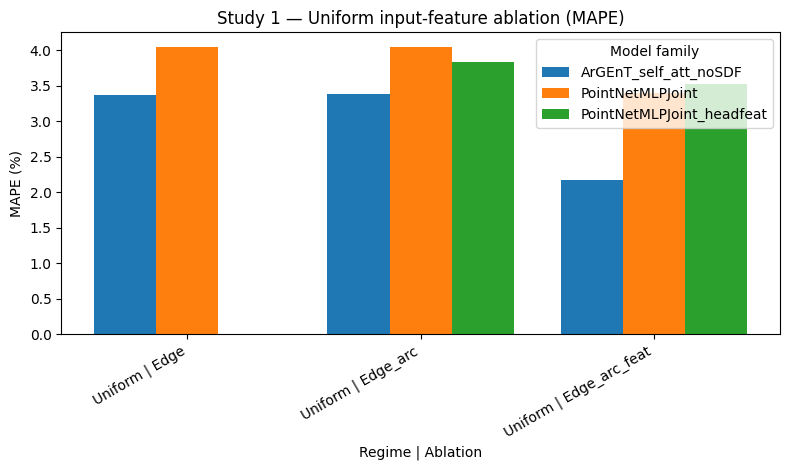

In [30]:
plot_study_mape(study1_df, 'Study 1 — Uniform input-feature ablation (MAPE)')


- `MAPE (%)` and `Max_PE (%)` are the primary ranking metrics for `LogLife` in this study.
- The table isolates how adding arc-length and derivative features changes life-prediction error under Uniform sampling.
- Use `MPE (%)` to identify systematic over- or under-prediction bias.


## Study 2: Input Feature Ablation — Zonal Regime

Ablations: `Edge`, `Edge_arc`, `Edge_arc_feat`, `Edge_zoneID`  
Models: `Adapted ArGEnT-inspired attention operator`, `GC-PointNet`, `GC-PointNet_headfeat`


In [31]:
study2_df = get_study_results(
    metrics_long,
    regimes=['Zonal'],
    ablations=['Edge', 'Edge_arc', 'Edge_arc_feat', 'Edge_zoneID'],
    models=['ArGEnT_self_att_noSDF', 'PointNetMLPJoint', 'PointNetMLPJoint_headfeat'],
)


In [32]:
render_study_table(study2_df, 'Study 2 Summary')


,regime,ablation,model_family,target,MAPE (%),MPE (%),Max_PE (%),RMSE_raw,MSE_raw_life,R2_raw_life,MSE,RMSE,MAE,R2 (log)
0,Zonal,Edge,ArGEnT_self_att_noSDF,LogLife,4.034,0.618,1363.206,25987350.673,675342394977505.500,0.9961,0.002301,0.047971,0.016709,0.9988
1,Zonal,Edge,ArGEnT_self_att_noSDF,Stress,N/A,N/A,N/A,N/A,N/A,N/A,42.005374,6.481155,2.104371,0.9987
2,Zonal,Edge,PointNetMLPJoint,LogLife,4.743,1.040,2437.375,40462504.681,1637214285073731.250,0.9905,0.002326,0.048230,0.019702,0.9988
3,Zonal,Edge,PointNetMLPJoint,Stress,N/A,N/A,N/A,N/A,N/A,N/A,35.777999,5.981471,2.359031,0.9989
4,Zonal,Edge_arc,ArGEnT_self_att_noSDF,LogLife,4.289,0.681,3086.912,26435112.206,698815157320621.000,0.9960,0.002376,0.048740,0.017848,0.9988
5,Zonal,Edge_arc,ArGEnT_self_att_noSDF,Stress,N/A,N/A,N/A,N/A,N/A,N/A,42.990927,6.556747,2.242411,0.9987
6,Zonal,Edge_arc,PointNetMLPJoint,LogLife,4.840,0.999,3372.628,41039409.504,1684233132477804.500,0.9903,0.002285,0.047798,0.020016,0.9989
7,Zonal,Edge_arc,PointNetMLPJoint,Stress,N/A,N/A,N/A,N/A,N/A,N/A,34.288880,5.855671,2.373381,0.9990
8,Zonal,Edge_arc,PointNetMLPJoint_headfeat,LogLife,4.683,0.594,1784.690,38902642.291,1513415577247139.000,0.9912,0.002339,0.048361,0.019446,0.9988
9,Zonal,Edge_arc,PointNetMLPJoint_headfeat,Stress,N/A,N/A,N/A,N/A,N/A,N/A,36.284792,6.023686,2.342818,0.9989


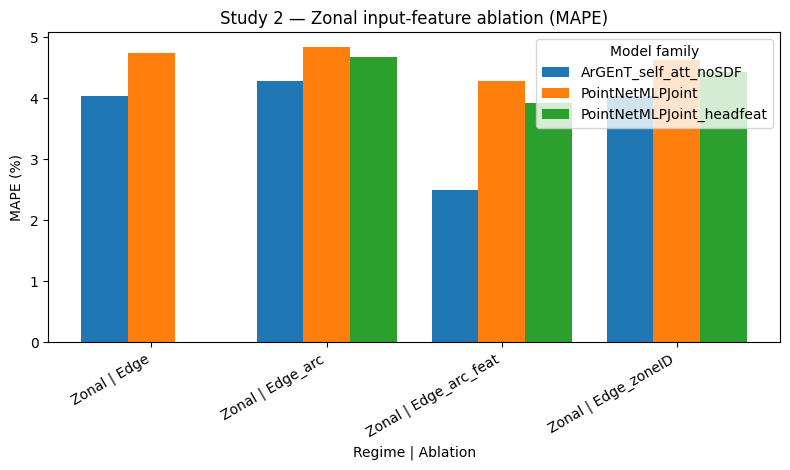

In [33]:
plot_study_mape(study2_df, 'Study 2 — Zonal input-feature ablation (MAPE)')


- This study adds `Edge_zoneID` to test whether explicit zone encoding helps under Zonal sampling.
- `MAPE (%)` and `Max_PE (%)` indicate whether improvements are robust or driven by outliers.
- Compare `MPE (%)` signs to track bias shifts introduced by each ablation.


## Study 3: Uniform vs. Zonal — Effect of Regime

Fixed ablation: `Edge`  
Models: `Adapted ArGEnT-inspired attention operator`, `GC-PointNet`


In [34]:
study3_df = get_study_results(
    metrics_long,
    regimes=['Uniform', 'Zonal'],
    ablations=['Edge'],
    models=['ArGEnT_self_att_noSDF', 'PointNetMLPJoint'],
)


In [35]:
render_study_table(study3_df, 'Study 3 Summary')


,regime,ablation,model_family,target,MAPE (%),MPE (%),Max_PE (%),RMSE_raw,MSE_raw_life,R2_raw_life,MSE,RMSE,MAE,R2 (log)
0,Uniform,Edge,ArGEnT_self_att_noSDF,LogLife,3.377,0.329,1424.410,16615926.339,276089008119568.281,0.9990,0.001320,0.036332,0.014296,0.9993
1,Uniform,Edge,ArGEnT_self_att_noSDF,Stress,N/A,N/A,N/A,N/A,N/A,N/A,42.369682,6.509200,2.136849,0.9987
2,Zonal,Edge,ArGEnT_self_att_noSDF,LogLife,4.034,0.618,1363.206,25987350.673,675342394977505.500,0.9961,0.002301,0.047971,0.016709,0.9988
3,Zonal,Edge,ArGEnT_self_att_noSDF,Stress,N/A,N/A,N/A,N/A,N/A,N/A,42.005374,6.481155,2.104371,0.9987
4,Uniform,Edge,PointNetMLPJoint,LogLife,4.053,0.810,1417.717,27981896.173,782986513453591.500,0.9972,0.001489,0.038585,0.017077,0.9992
5,Uniform,Edge,PointNetMLPJoint,Stress,N/A,N/A,N/A,N/A,N/A,N/A,36.100497,6.008369,2.367020,0.9989
6,Zonal,Edge,PointNetMLPJoint,LogLife,4.743,1.040,2437.375,40462504.681,1637214285073731.250,0.9905,0.002326,0.048230,0.019702,0.9988
7,Zonal,Edge,PointNetMLPJoint,Stress,N/A,N/A,N/A,N/A,N/A,N/A,35.777999,5.981471,2.359031,0.9989


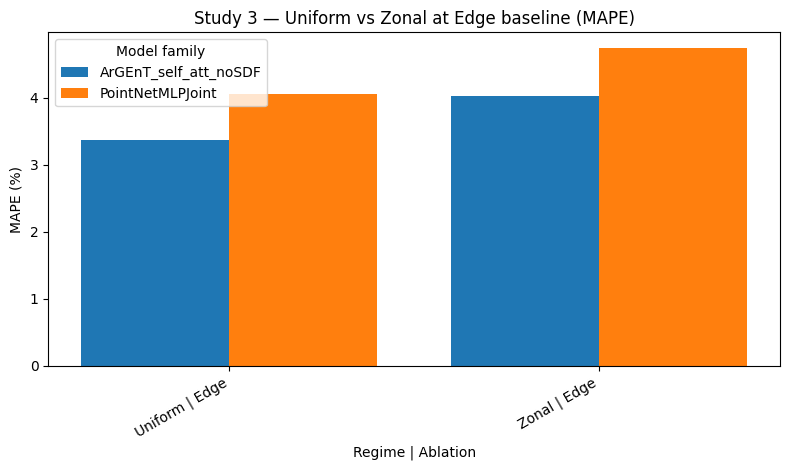

In [36]:
plot_study_mape(study3_df, 'Study 3 — Uniform vs Zonal at Edge baseline (MAPE)')


- This paired comparison quantifies regime difficulty using the same baseline feature set.
- Higher `MAPE (%)`/`Max_PE (%)` in Zonal rows indicates a harder prediction setting.
- Cross-model consistency in the direction of change strengthens the regime-level conclusion.


## Study 4: Effect of Proximity Feature — Edge vs. Edge_Prox

Ablations: `Edge`, `Edge_Prox`  
Regimes: Uniform and Zonal  
Models: `Adapted ArGEnT-inspired attention operator`, `GC-PointNet`


In [37]:
study4_df = get_study_results(
    metrics_long,
    regimes=['Uniform', 'Zonal'],
    ablations=['Edge', 'Edge_Prox'],
    models=['ArGEnT_self_att_noSDF', 'PointNetMLPJoint'],
)


In [38]:
render_study_table(study4_df, 'Study 4 Summary')


,regime,ablation,model_family,target,MAPE (%),MPE (%),Max_PE (%),RMSE_raw,MSE_raw_life,R2_raw_life,MSE,RMSE,MAE,R2 (log)
0,Uniform,Edge,ArGEnT_self_att_noSDF,LogLife,3.377,0.329,1424.410,16615926.339,276089008119568.281,0.9990,0.001320,0.036332,0.014296,0.9993
1,Uniform,Edge,ArGEnT_self_att_noSDF,Stress,N/A,N/A,N/A,N/A,N/A,N/A,42.369682,6.509200,2.136849,0.9987
2,Zonal,Edge,ArGEnT_self_att_noSDF,LogLife,4.034,0.618,1363.206,25987350.673,675342394977505.500,0.9961,0.002301,0.047971,0.016709,0.9988
3,Zonal,Edge,ArGEnT_self_att_noSDF,Stress,N/A,N/A,N/A,N/A,N/A,N/A,42.005374,6.481155,2.104371,0.9987
4,Uniform,Edge,PointNetMLPJoint,LogLife,4.053,0.810,1417.717,27981896.173,782986513453591.500,0.9972,0.001489,0.038585,0.017077,0.9992
5,Uniform,Edge,PointNetMLPJoint,Stress,N/A,N/A,N/A,N/A,N/A,N/A,36.100497,6.008369,2.367020,0.9989
6,Zonal,Edge,PointNetMLPJoint,LogLife,4.743,1.040,2437.375,40462504.681,1637214285073731.250,0.9905,0.002326,0.048230,0.019702,0.9988
7,Zonal,Edge,PointNetMLPJoint,Stress,N/A,N/A,N/A,N/A,N/A,N/A,35.777999,5.981471,2.359031,0.9989
8,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,LogLife,1.850,0.089,68084.197,13273104.820,176175311560494.531,0.9987,0.000195,0.013951,0.007913,0.9999
9,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,Stress,N/A,N/A,N/A,N/A,N/A,N/A,3.863568,1.965596,1.007484,0.9998


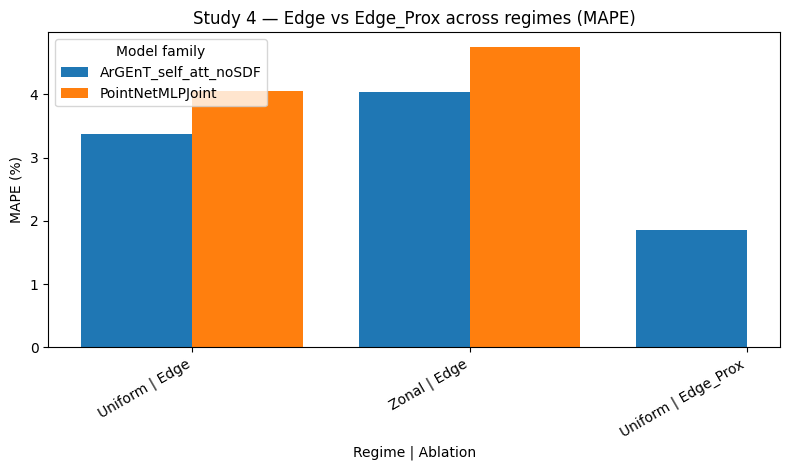

In [39]:
plot_study_mape(study4_df, 'Study 4 — Edge vs Edge_Prox across regimes (MAPE)')


- This study isolates the impact of proximity representation relative to the Edge baseline.
- Read Uniform and Zonal rows side-by-side to see if proximity helps consistently by regime.
- `Max_PE (%)` highlights whether proximity mainly reduces extreme local failures.


## Study 5: Stress as Input — Edge vs. Edge_no_stress

Ablations: `Edge`, `Edge_no_stress`  
Regimes: Uniform and Zonal  
Models: `Adapted ArGEnT-inspired attention operator`, `GC-PointNet`


In [40]:
study5_df = get_study_results(
    metrics_long,
    regimes=['Uniform', 'Zonal'],
    ablations=['Edge', 'Edge_no_stress'],
    models=['ArGEnT_self_att_noSDF', 'PointNetMLPJoint'],
)


In [41]:
render_study_table(study5_df, 'Study 5 Summary')


,regime,ablation,model_family,target,MAPE (%),MPE (%),Max_PE (%),RMSE_raw,MSE_raw_life,R2_raw_life,MSE,RMSE,MAE,R2 (log)
0,Uniform,Edge,ArGEnT_self_att_noSDF,LogLife,3.377,0.329,1424.410,16615926.339,276089008119568.281,0.9990,0.001320,0.036332,0.014296,0.9993
1,Uniform,Edge,ArGEnT_self_att_noSDF,Stress,N/A,N/A,N/A,N/A,N/A,N/A,42.369682,6.509200,2.136849,0.9987
2,Zonal,Edge,ArGEnT_self_att_noSDF,LogLife,4.034,0.618,1363.206,25987350.673,675342394977505.500,0.9961,0.002301,0.047971,0.016709,0.9988
3,Zonal,Edge,ArGEnT_self_att_noSDF,Stress,N/A,N/A,N/A,N/A,N/A,N/A,42.005374,6.481155,2.104371,0.9987
4,Uniform,Edge,PointNetMLPJoint,LogLife,4.053,0.810,1417.717,27981896.173,782986513453591.500,0.9972,0.001489,0.038585,0.017077,0.9992
5,Uniform,Edge,PointNetMLPJoint,Stress,N/A,N/A,N/A,N/A,N/A,N/A,36.100497,6.008369,2.367020,0.9989
6,Zonal,Edge,PointNetMLPJoint,LogLife,4.743,1.040,2437.375,40462504.681,1637214285073731.250,0.9905,0.002326,0.048230,0.019702,0.9988
7,Zonal,Edge,PointNetMLPJoint,Stress,N/A,N/A,N/A,N/A,N/A,N/A,35.777999,5.981471,2.359031,0.9989
8,Uniform,Edge_no_stress,ArGEnT_self_att_noSDF,LogLife,3.227,0.426,1724.670,15203143.513,231135572680756.594,0.9992,0.001317,0.036294,0.013630,0.9993
9,Uniform,Edge_no_stress,ArGEnT_self_att_noSDF,Stress,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A


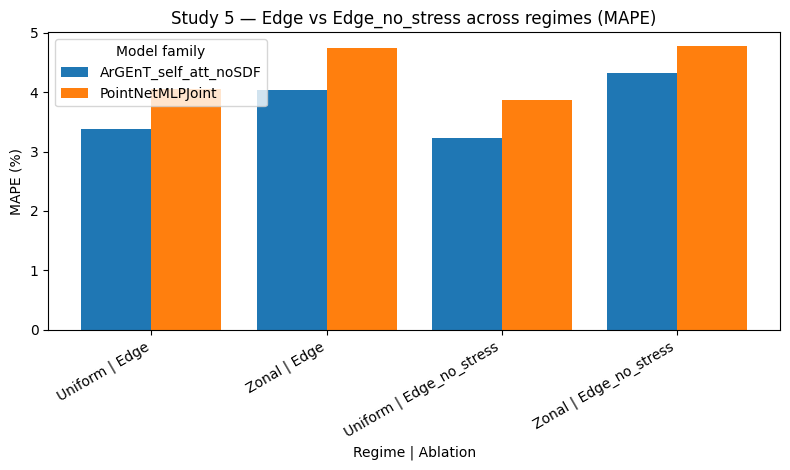

In [42]:
plot_study_mape(study5_df, 'Study 5 — Edge vs Edge_no_stress across regimes (MAPE)')


- This ablation tests how much stress-target coupling contributes to life prediction quality.
- Compare `Edge_no_stress` against `Edge` using `MAPE (%)` as the headline metric.
- Use `MPE (%)` and `Max_PE (%)` to identify bias and worst-case penalties from removing stress.


## Critical-region diagnostics

Pooled Stress/LogLife metrics above treat every node equally. The cells below add the
physically important **local/low-life** view: LogLife criticality bins, per-zone/subzone
errors, and per-geometry critical-node/critical-life metrics — computed once from
`node_results_df` and reused by every study/figure below.



In [43]:
bin_metrics_df = eh.loglife_bin_metrics(node_results_df)
zone_metrics_df = eh.zone_metrics_from_nodes(node_results_df, label_col='subzone_name')
geom_metrics_df = eh.geometry_level_metrics(node_results_df)
geom_summary_df = eh.geometry_metrics_summary(geom_metrics_df)

eh.save_table(bin_metrics_df, OUTPUT_DIR, 'loglife_bin_metrics')
eh.save_table(zone_metrics_df, OUTPUT_DIR, 'subzone_loglife_metrics')
eh.save_table(geom_metrics_df, OUTPUT_DIR, 'geometry_level_metrics')
eh.save_table(geom_summary_df, OUTPUT_DIR, 'geometry_level_summary')

display(Markdown('### LogLife criticality bins (all / <4 / <3 / <2 decades)'))
display(bin_metrics_df)

display(Markdown('### Per-subzone LogLife MAE/RMSE'))
display(zone_metrics_df)

display(Markdown('### Geometry-level summary (median / p90 / worst-case across evaluated geometries)'))
display(geom_summary_df)


### LogLife criticality bins (all / <4 / <3 / <2 decades)

,regime,ablation,model_family,bin,n_nodes,MAE,RMSE,signed_mean_error,max_abs_error,unstable
0,Uniform,Edge,ArGEnT_self_att_noSDF,all,679000,0.014296,0.036332,-0.000187,1.183102,False
1,Uniform,Edge,ArGEnT_self_att_noSDF,LogLife<4,6184,0.137743,0.166123,0.008762,0.674879,False
2,Uniform,Edge,ArGEnT_self_att_noSDF,LogLife<3,1378,0.169878,0.185160,0.108261,0.458867,False
3,Uniform,Edge,ArGEnT_self_att_noSDF,LogLife<2,0,NaN,NaN,NaN,NaN,True
4,Uniform,Edge,PointNetMLPJoint,all,679000,0.017077,0.038585,0.001697,2.543487,False
...,...,...,...,...,...,...,...,...,...,...
127,Zonal,Edge_zoneID,PointNetMLPJoint,LogLife<2,1013,0.106798,0.149353,0.050850,0.656639,False
128,Zonal,Edge_zoneID,PointNetMLPJoint_headfeat,all,679000,0.018439,0.045458,0.001513,2.761932,False
129,Zonal,Edge_zoneID,PointNetMLPJoint_headfeat,LogLife<4,13071,0.101858,0.146029,0.008105,1.220685,False
130,Zonal,Edge_zoneID,PointNetMLPJoint_headfeat,LogLife<3,4449,0.105856,0.150194,-0.000698,1.170278,False


### Per-subzone LogLife MAE/RMSE

,regime,ablation,model_family,subzone_name,n_nodes,MAE,RMSE,status
0,Uniform,Edge,ArGEnT_self_att_noSDF,bore,124481,0.008270,0.011296,ok
1,Uniform,Edge,ArGEnT_self_att_noSDF,lower_transition,66642,0.037679,0.076688,ok
2,Uniform,Edge,ArGEnT_self_att_noSDF,web,194101,0.005014,0.008617,ok
3,Uniform,Edge,ArGEnT_self_att_noSDF,upper_transition,52133,0.023314,0.037532,ok
4,Uniform,Edge,ArGEnT_self_att_noSDF,rim_main,86324,0.008275,0.014202,ok
...,...,...,...,...,...,...,...,...
292,Zonal,Edge_zoneID,PointNetMLPJoint_headfeat,rim_main,86324,0.014185,0.024509,ok
293,Zonal,Edge_zoneID,PointNetMLPJoint_headfeat,front_cgroove,35036,0.056428,0.127289,ok
294,Zonal,Edge_zoneID,PointNetMLPJoint_headfeat,rear_arm_neck,65580,0.030766,0.058202,ok
295,Zonal,Edge_zoneID,PointNetMLPJoint_headfeat,rear_arm_land,22150,0.022373,0.041825,ok


### Geometry-level summary (median / p90 / worst-case across evaluated geometries)

,regime,ablation,model_family,n_geometries,min_loglife_error_decades_median_abs,min_loglife_error_decades_p90_abs,min_loglife_error_decades_worst_abs,crit_node_distance_mm_median_abs,crit_node_distance_mm_p90_abs,crit_node_distance_mm_worst_abs,max_stress_error_median_abs,max_stress_error_p90_abs,max_stress_error_worst_abs,frac_same_zone_critical
0,Uniform,Edge,ArGEnT_self_att_noSDF,1000,0.158462,0.234522,0.420582,0.0,0.411532,70.997582,48.300354,69.096057,115.876709,0.988
1,Uniform,Edge,PointNetMLPJoint,1000,0.047511,0.149489,0.353036,0.0,0.410268,69.805569,13.898743,44.318860,108.588379,0.987
2,Uniform,Edge_Prox,ArGEnT_self_att_noSDF,1000,0.028209,0.067218,0.153898,0.0,0.386691,68.835274,7.608826,18.331079,47.295410,0.999
3,Uniform,Edge_arc,ArGEnT_self_att_noSDF,1000,0.160666,0.231340,0.355857,0.0,0.411552,69.918195,48.612610,69.051660,100.319580,0.989
4,Uniform,Edge_arc,PointNetMLPJoint,1000,0.052506,0.149398,0.310963,0.0,0.411741,69.781542,15.369385,45.362000,100.795288,0.988
5,Uniform,Edge_arc,PointNetMLPJoint_headfeat,1000,0.053870,0.149672,0.519316,0.0,0.411217,69.781542,14.536560,41.100879,131.796997,0.988
6,Uniform,Edge_arc_feat,ArGEnT_self_att_noSDF,1000,0.018243,0.052424,0.246381,0.0,0.000000,69.145533,4.895447,13.819812,77.245850,0.996
7,Uniform,Edge_arc_feat,PointNetMLPJoint,1000,0.047624,0.147502,0.409474,0.0,0.410803,69.781542,13.490723,43.672437,117.057617,0.989
8,Uniform,Edge_arc_feat,PointNetMLPJoint_headfeat,1000,0.054048,0.148154,0.389540,0.0,0.411219,68.718779,15.293518,43.711426,118.457642,0.995
9,Uniform,Edge_no_stress,ArGEnT_self_att_noSDF,1000,0.161667,0.242595,0.344035,0.0,0.411741,70.997582,NaN,NaN,NaN,0.984


### Summary diagnostic figures — principal comparison (`Zonal + Edge`)



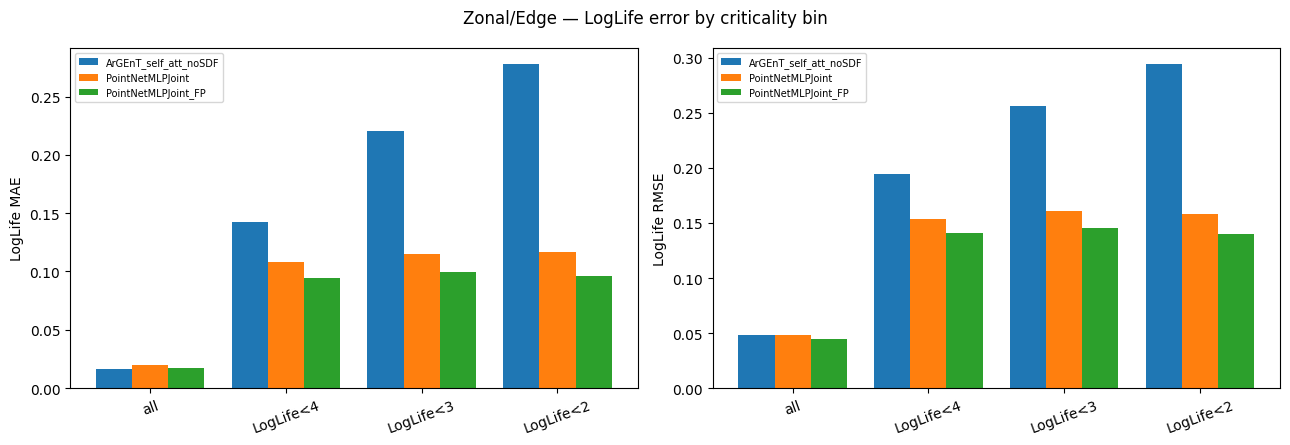

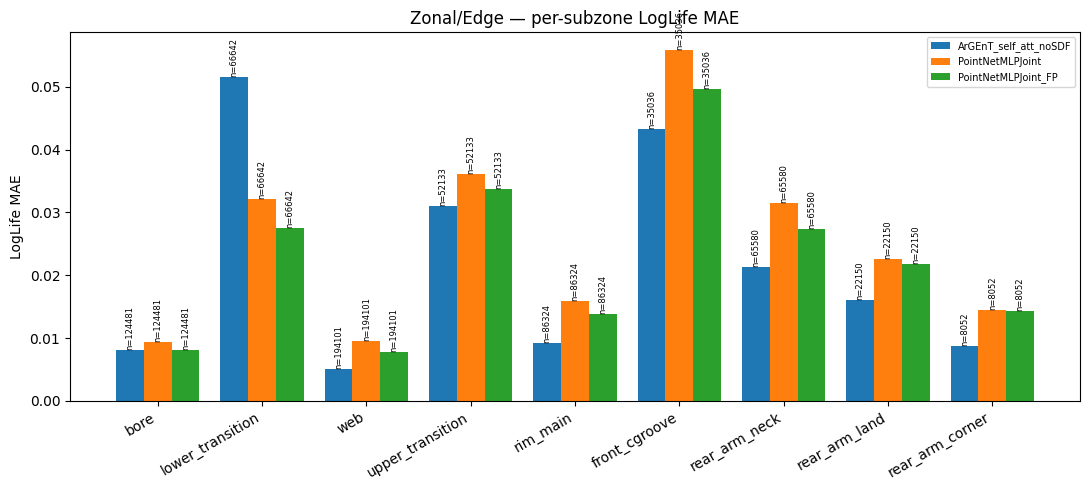

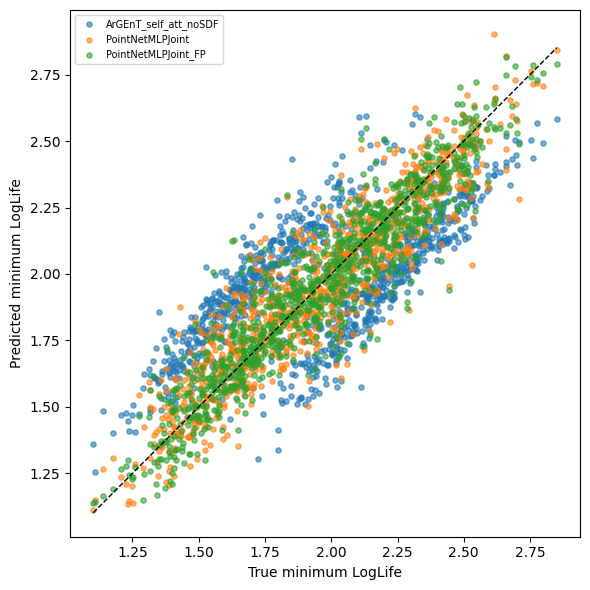

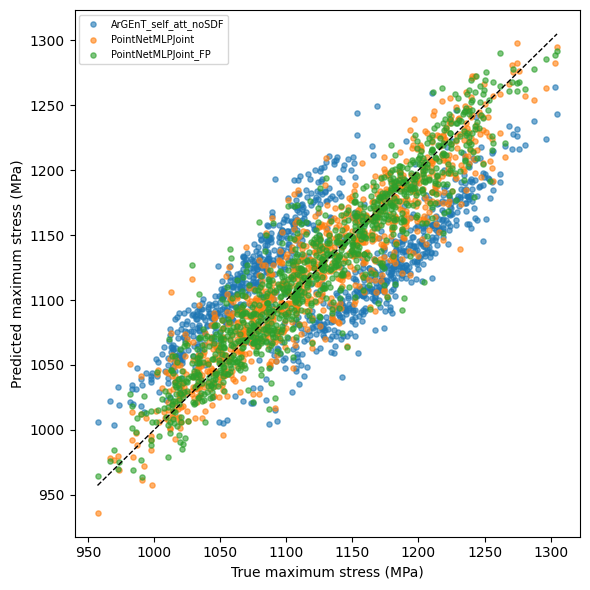

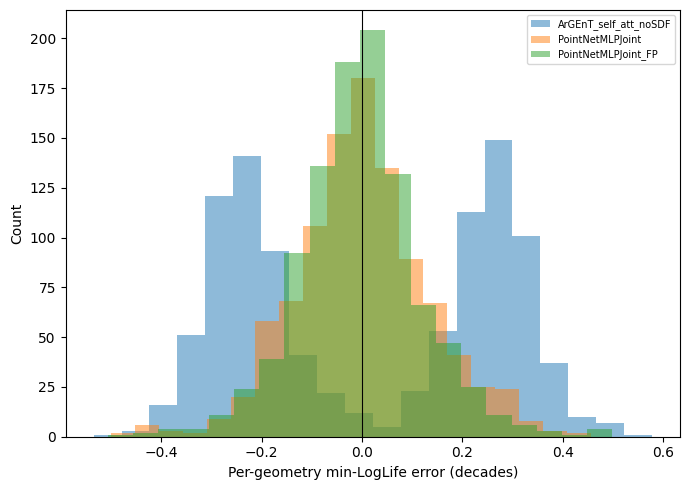

### ArGEnT-minus-FP paired critical-life error difference
`argent_minus_fp > 0` → FP has smaller absolute min-LogLife error for that geometry (FP better). `< 0` → ArGEnT is better for that geometry.

,sample_id,argent_abs_error,fp_abs_error,argent_minus_fp
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,2466.656000,0.246507,0.090779,0.155727
std,1475.210263,0.083750,0.080459,0.116189
min,8.000000,0.001660,0.000002,-0.333532
25%,1147.750000,0.196341,0.033101,0.085711
50%,2501.500000,0.249322,0.070035,0.167275
75%,3718.250000,0.300556,0.124010,0.237360
max,4998.000000,0.577861,0.506477,0.531344


In [44]:
principal_bins = bin_metrics_df[(bin_metrics_df['regime'] == PRINCIPAL_REGIME) & (bin_metrics_df['ablation'] == PRINCIPAL_ABLATION)]
principal_zones = zone_metrics_df[(zone_metrics_df['regime'] == PRINCIPAL_REGIME) & (zone_metrics_df['ablation'] == PRINCIPAL_ABLATION)]
principal_geom = geom_metrics_df[(geom_metrics_df['regime'] == PRINCIPAL_REGIME) & (geom_metrics_df['ablation'] == PRINCIPAL_ABLATION)]

if principal_bins.empty:
    display(Markdown(f'**No evaluated data for principal comparison {PRINCIPAL_REGIME}/{PRINCIPAL_ABLATION} in this runtime.**'))
else:
    eh.plot_bin_bar(principal_bins, f'{PRINCIPAL_REGIME}/{PRINCIPAL_ABLATION} — LogLife error by criticality bin',
                     out_dir=FIGURES_DIR, filename='principal_loglife_bin_mae_rmse')
    plt.show()
    eh.plot_zone_bar(principal_zones, f'{PRINCIPAL_REGIME}/{PRINCIPAL_ABLATION} — per-subzone LogLife MAE',
                      out_dir=FIGURES_DIR, filename='principal_subzone_mae')
    plt.show()
    eh.plot_geometry_scatter(principal_geom, out_dir=FIGURES_DIR, filename_prefix='principal')
    plt.show()

    if {'ArGEnT_self_att_noSDF', 'PointNetMLPJoint_FP'}.issubset(set(principal_geom['model_family'])):
        paired_df = eh.paired_argent_fp_diff(geom_metrics_df[geom_metrics_df['ablation'] == PRINCIPAL_ABLATION])
        eh.save_table(paired_df, OUTPUT_DIR, 'argent_vs_fp_paired_critical_life_error')
        display(Markdown(
            '### ArGEnT-minus-FP paired critical-life error difference\n'
            '`argent_minus_fp > 0` → FP has smaller absolute min-LogLife error for that geometry (FP better). '
            '`< 0` → ArGEnT is better for that geometry.'
        ))
        display(paired_df.describe())
    else:
        paired_df = pd.DataFrame()
        display(Markdown('FP and/or ArGEnT not both available for the principal comparison — paired diff skipped.'))


## Representative geometry selection and spatial figures (`Zonal + Edge`)

Three geometries are selected deterministically from the evaluation split (never from an
external example file): the **median** case, the **critical-life** case (lowest true
minimum LogLife), and the **model-disagreement** case (largest |ArGEnT − FP| absolute
critical-life error). The same three `sample_id`s are used for every model.



In [45]:
def read_geometry_params_from_h5(h5_filename: str, sample_id: int) -> Dict[str, Any]:
    h5_path = H5_DATASET_ROOT / h5_filename
    with h5py.File(h5_path, 'r') as f:
        key = f'sample_{sample_id:06d}'
        if key not in f['samples']:
            return {}
        grp = f['samples'][key]
        params = dict(grp['geometry_parameters_actual'].attrs) if 'geometry_parameters_actual' in grp else {}
        return {k: float(v) for k, v in params.items()}


principal_rows = selected_models_df[
    (selected_models_df['regime'] == PRINCIPAL_REGIME) & (selected_models_df['ablation'] == PRINCIPAL_ABLATION)
]
principal_h5 = principal_rows['h5_filename'].dropna().unique().tolist()

if principal_geom.empty or not principal_h5:
    display(Markdown('**No principal-comparison data available in this runtime — spatial figures skipped.**'))
    representative_ids: Dict[str, Any] = {}
else:
    representative_ids = eh.select_representative_geometries(
        geom_metrics_df, PRINCIPAL_REGIME, PRINCIPAL_ABLATION,
        argent_family='ArGEnT_self_att_noSDF', disagreement_family='PointNetMLPJoint_FP',
    )
    eh.save_json(representative_ids, OUTPUT_DIR, 'principal_representative_geometry_ids')
    h5_filename = principal_h5[0]

    display(Markdown(f'### Selected representative `sample_id`s ({PRINCIPAL_REGIME}/{PRINCIPAL_ABLATION})'))
    for case_name, sid in representative_ids.items():
        if sid is None:
            display(Markdown(f'- **{case_name}**: not available (insufficient shared models/geometries).'))
            continue
        params = read_geometry_params_from_h5(h5_filename, sid)
        row_for_case = principal_geom[principal_geom['sample_id'] == sid].iloc[0]
        display(Markdown(
            f"- **{case_name}**: `sample_id={sid}` — true min LogLife={row_for_case['true_min_loglife']:.3f} "
            f"(zone={row_for_case['true_crit_zone']}, subzone={row_for_case['true_crit_subzone']}), "
            f"true max stress={row_for_case['true_max_stress']:.2f} MPa\n\n"
            f"  geometry parameters (mm): {params}"
        ))


### Selected representative `sample_id`s (Zonal/Edge)

- **median**: `sample_id=2653` — true min LogLife=2.776 (zone=lower_transition, subzone=lower_transition), true max stress=969.99 MPa

  geometry parameters (mm): {'bore_height': 10.972572664843888, 'bore_radius_inner': 23.941420324827675, 'bore_thickness': 29.771709307757003, 'lower_fillet_radius': 2.137889937373566, 'lower_transition_height': 8.072067443062817, 'rim_height': 14.812708511840325, 'rim_thickness': 20.242408378221608, 'upper_fillet_radius': 2.680758843628607, 'upper_transition_height': 9.123820063302396, 'web_height': 39.83153109678343, 'web_thickness': 9.891379547974942}

- **critical_life**: `sample_id=1870` — true min LogLife=1.102 (zone=lower_transition, subzone=lower_transition), true max stress=1304.86 MPa

  geometry parameters (mm): {'bore_height': 11.090134576471554, 'bore_radius_inner': 23.955014532885595, 'bore_thickness': 29.69702162057587, 'lower_fillet_radius': 2.177963361956764, 'lower_transition_height': 7.629568080818468, 'rim_height': 15.379532623063009, 'rim_thickness': 20.23841269050795, 'upper_fillet_radius': 2.577438585025162, 'upper_transition_height': 9.399750694627315, 'web_height': 39.40740591755981, 'web_thickness': 9.875408927823031}

- **model_disagreement**: `sample_id=3973` — true min LogLife=2.111 (zone=lower_transition, subzone=lower_transition), true max stress=1091.33 MPa

  geometry parameters (mm): {'bore_height': 10.975305963349108, 'bore_radius_inner': 23.966975502911126, 'bore_thickness': 30.411283341947644, 'lower_fillet_radius': 2.2545802613259123, 'lower_transition_height': 7.721801335980206, 'rim_height': 14.60044339061121, 'rim_thickness': 20.38983312530951, 'upper_fillet_radius': 2.597174592465717, 'upper_transition_height': 8.666701503127953, 'web_height': 39.61065281842235, 'web_thickness': 9.714653616540467}

#### median — sample_id=2653

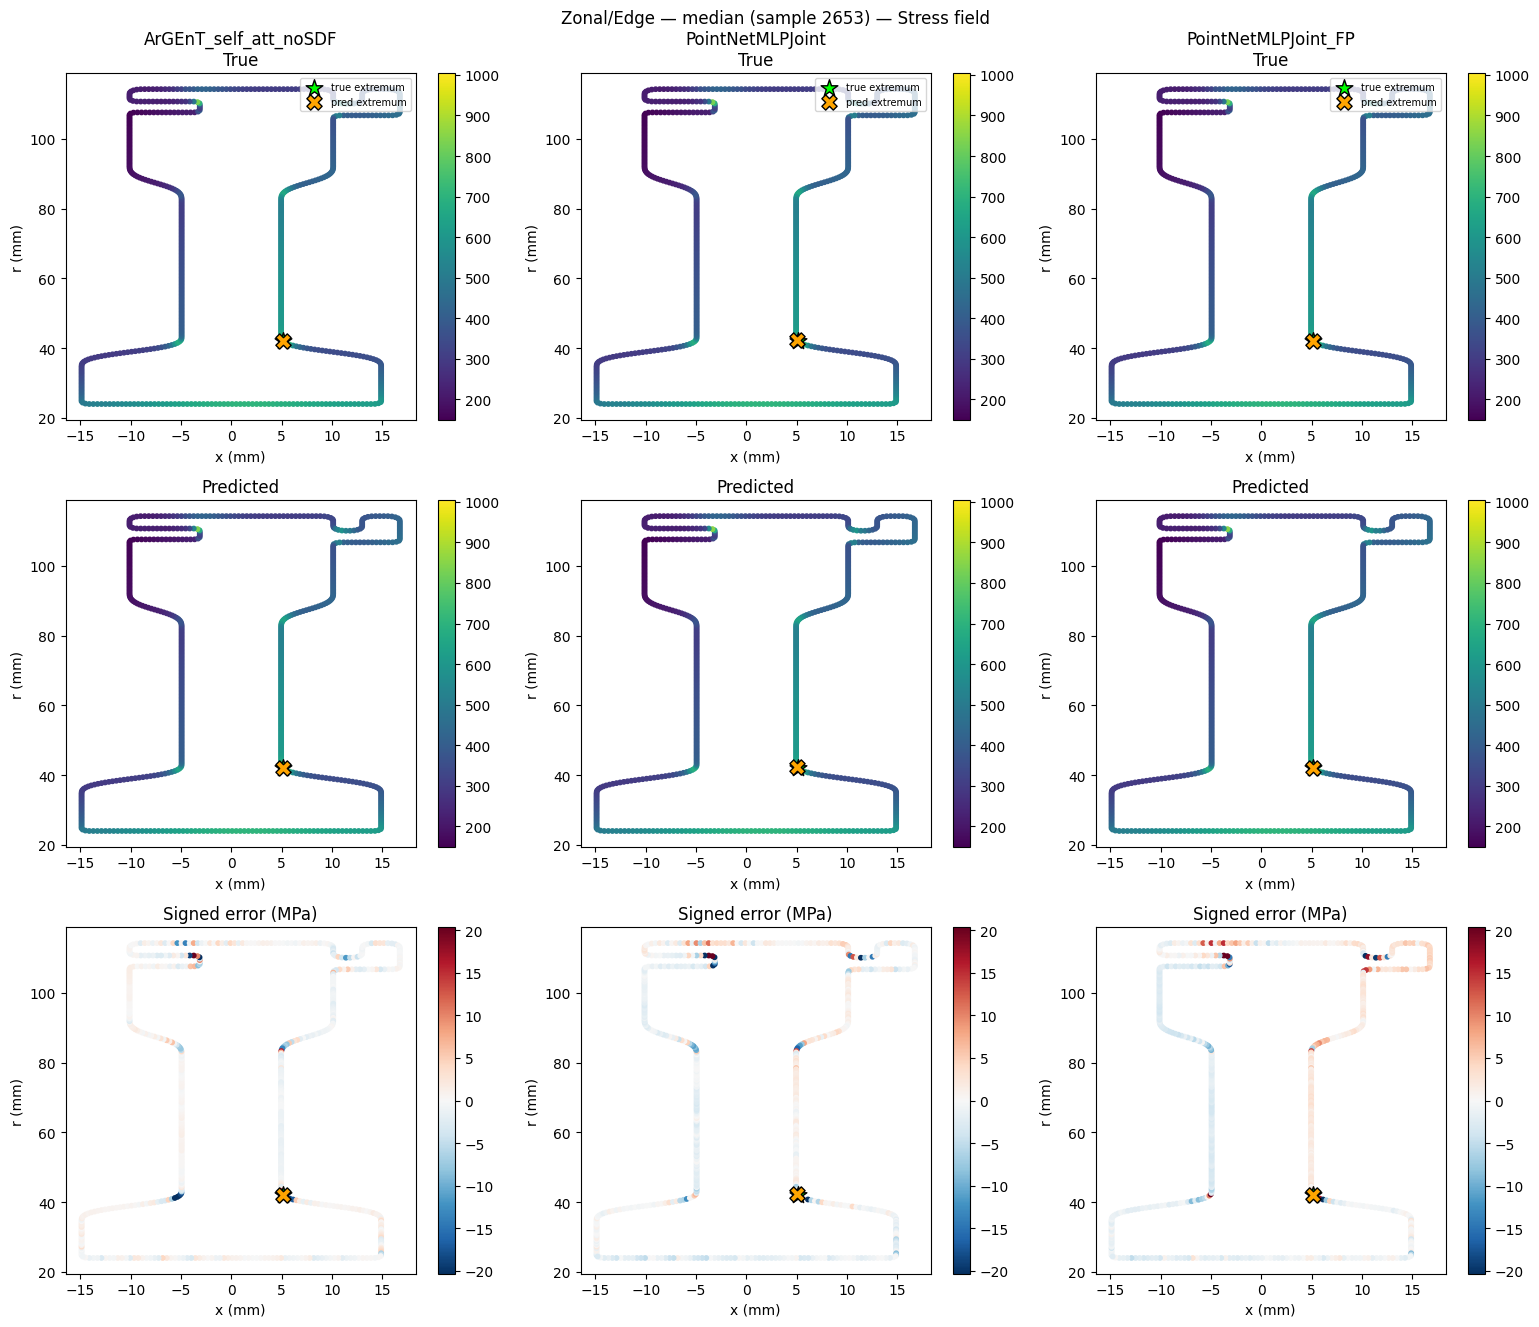

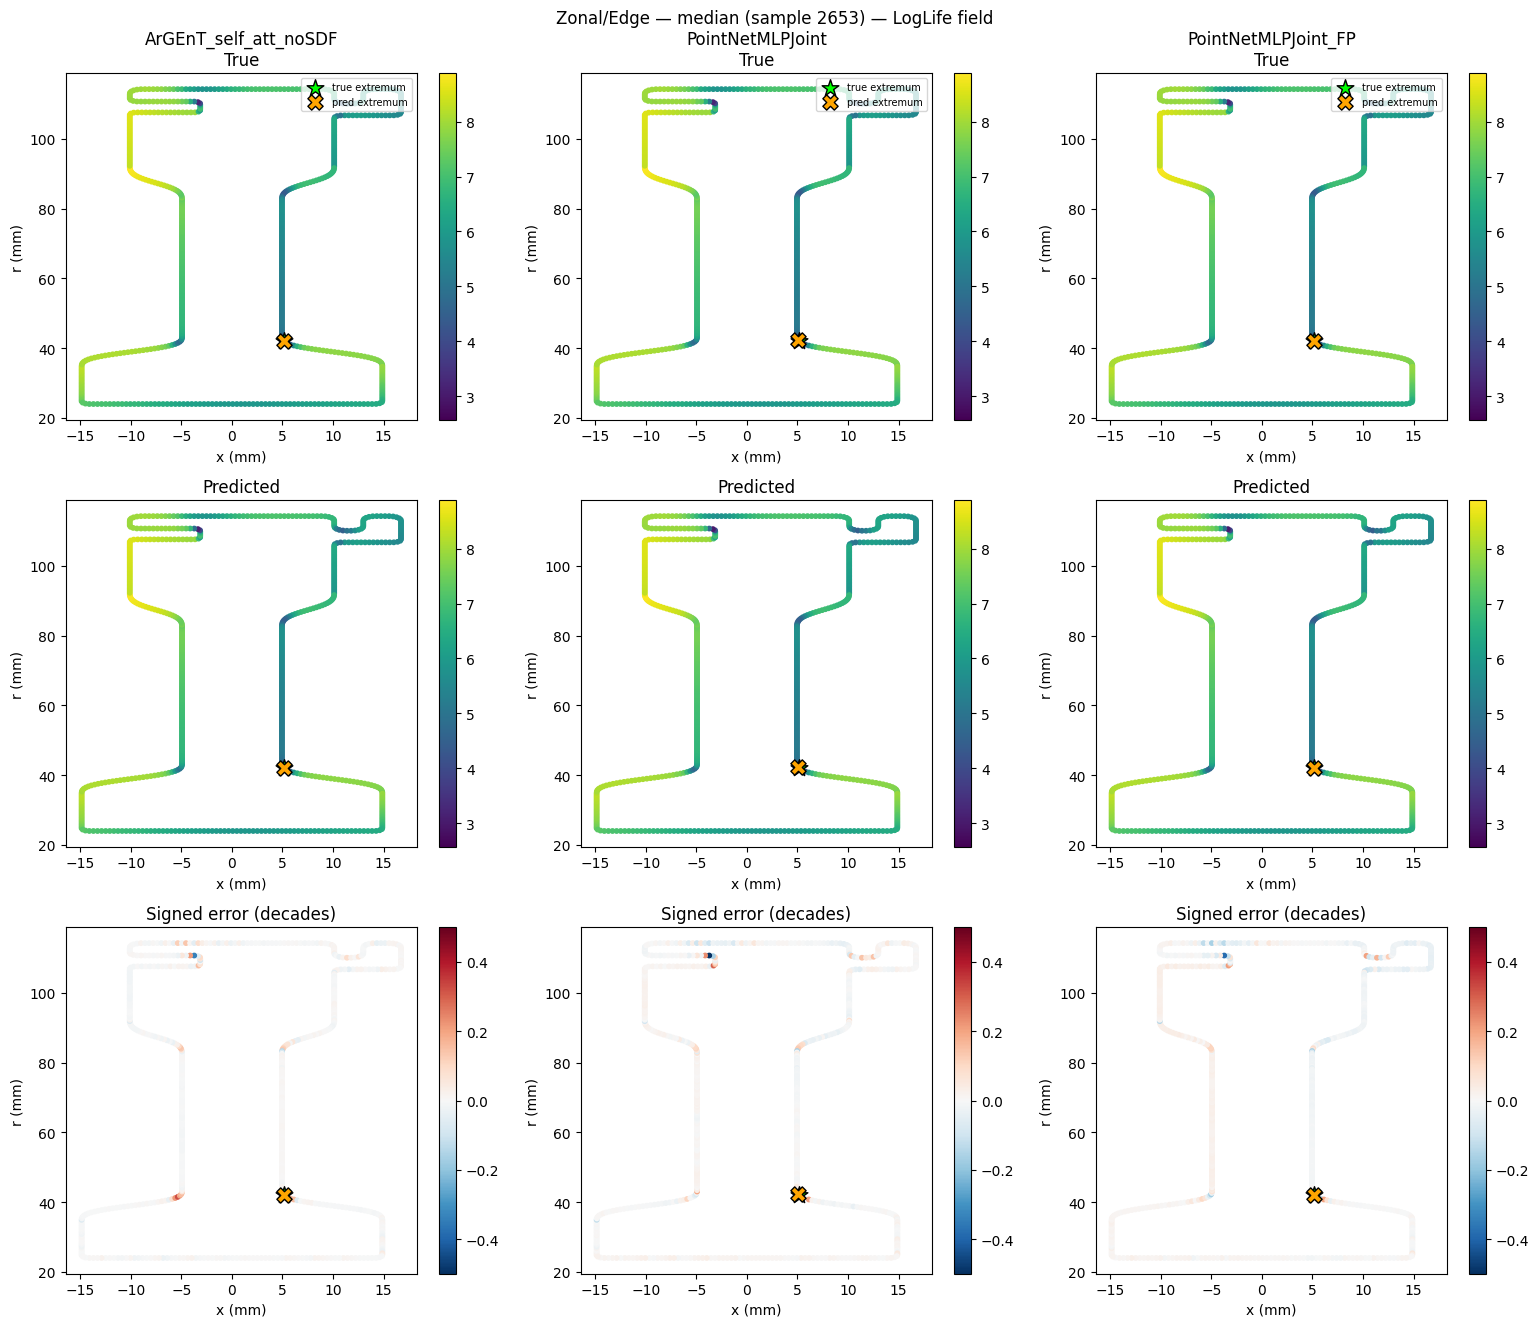

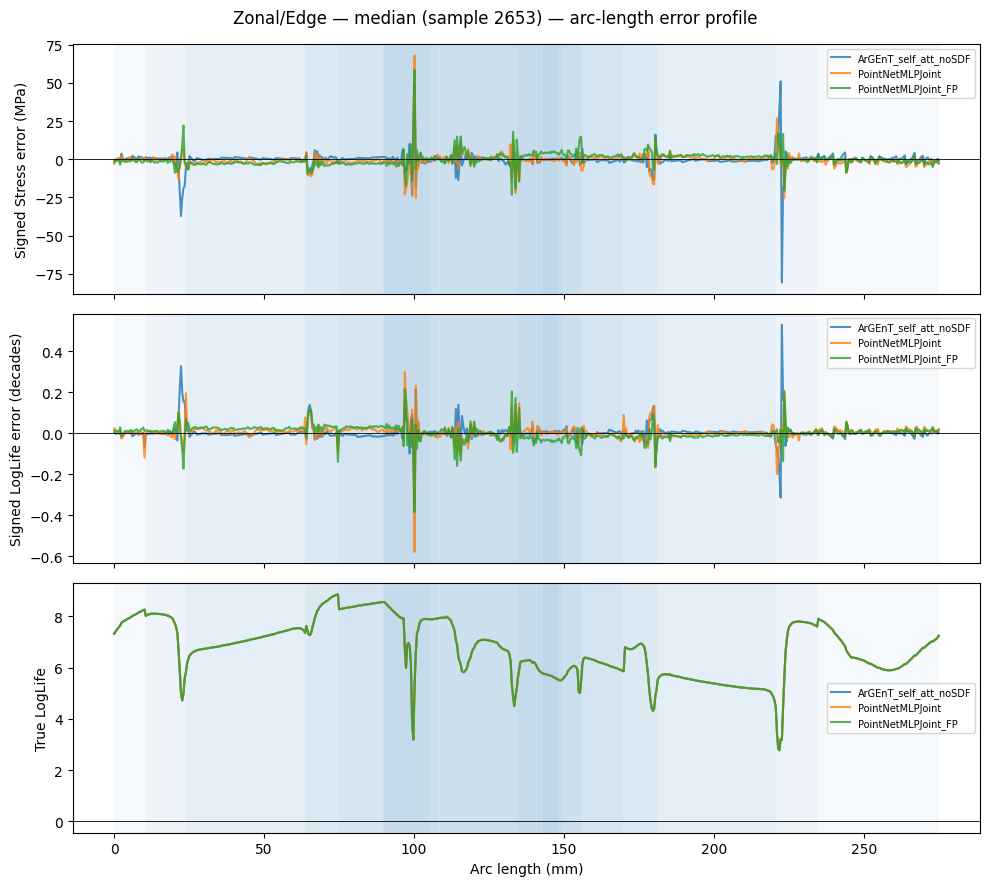

#### critical_life — sample_id=1870

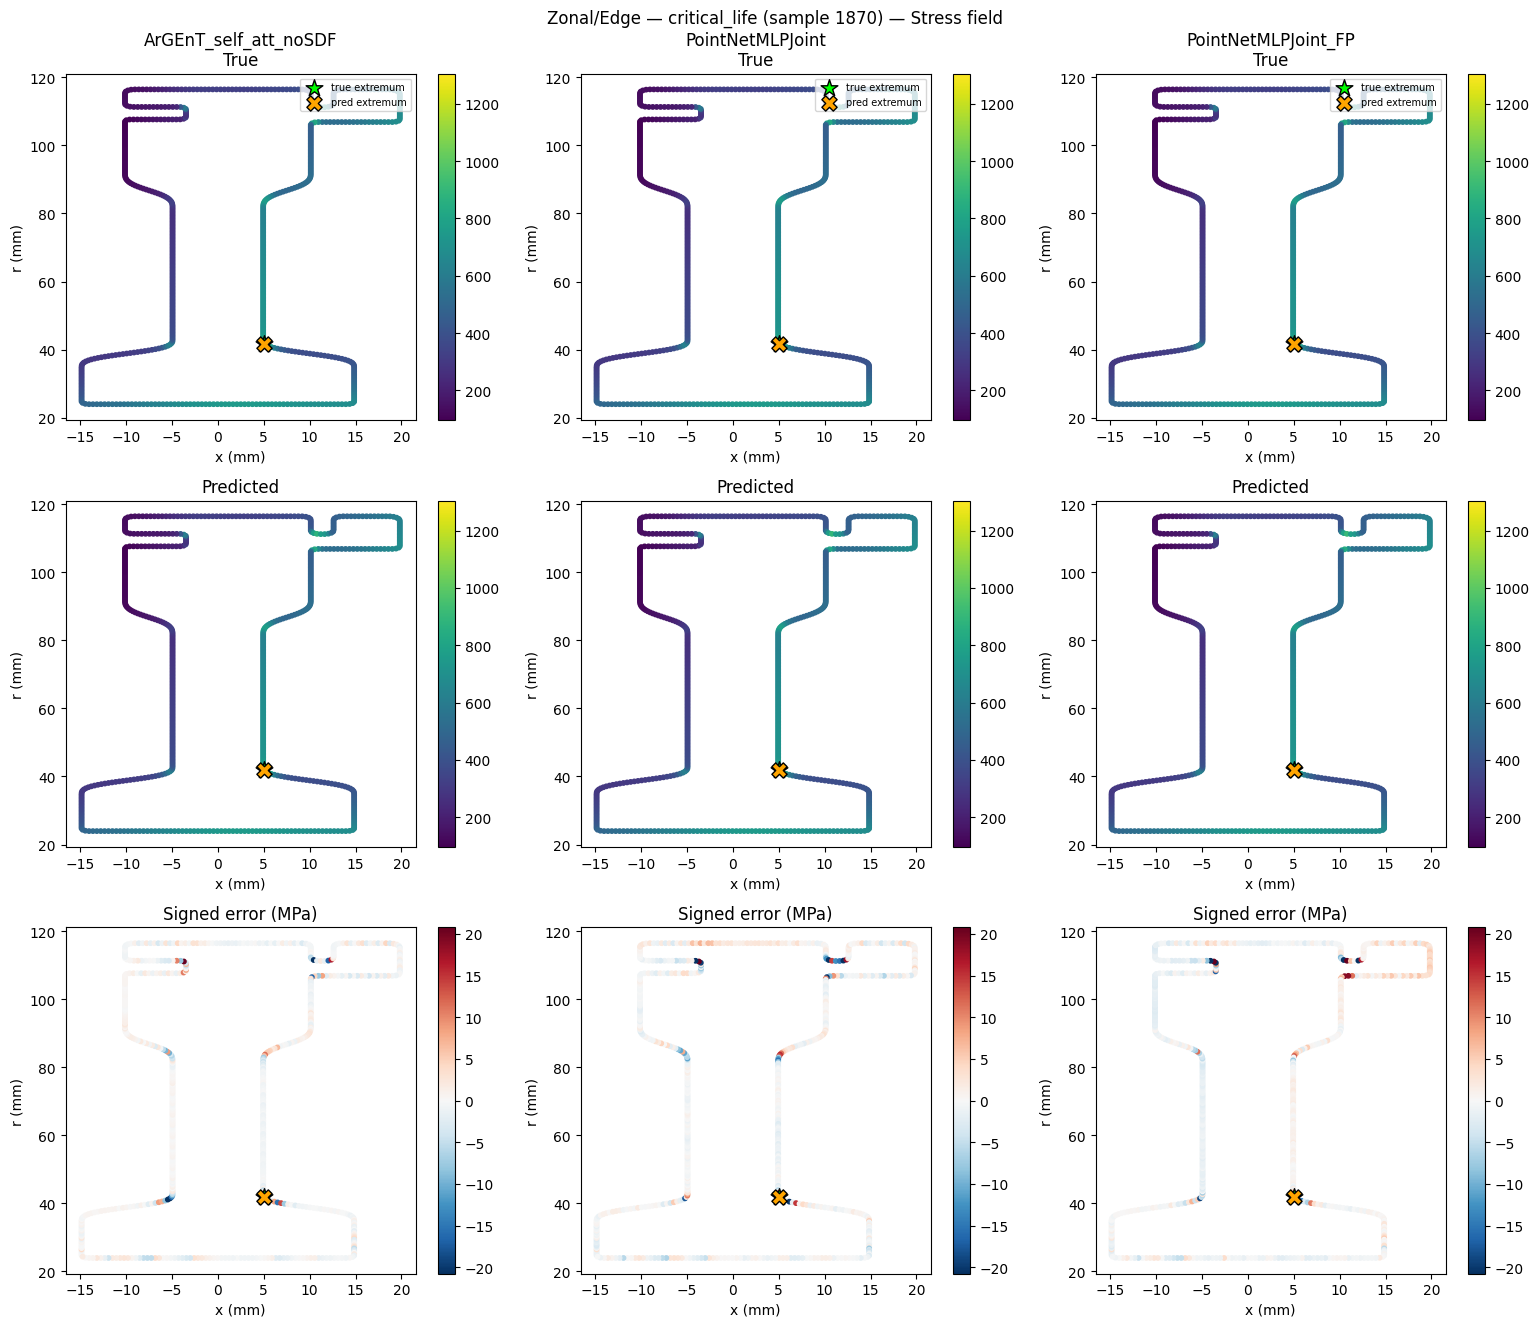

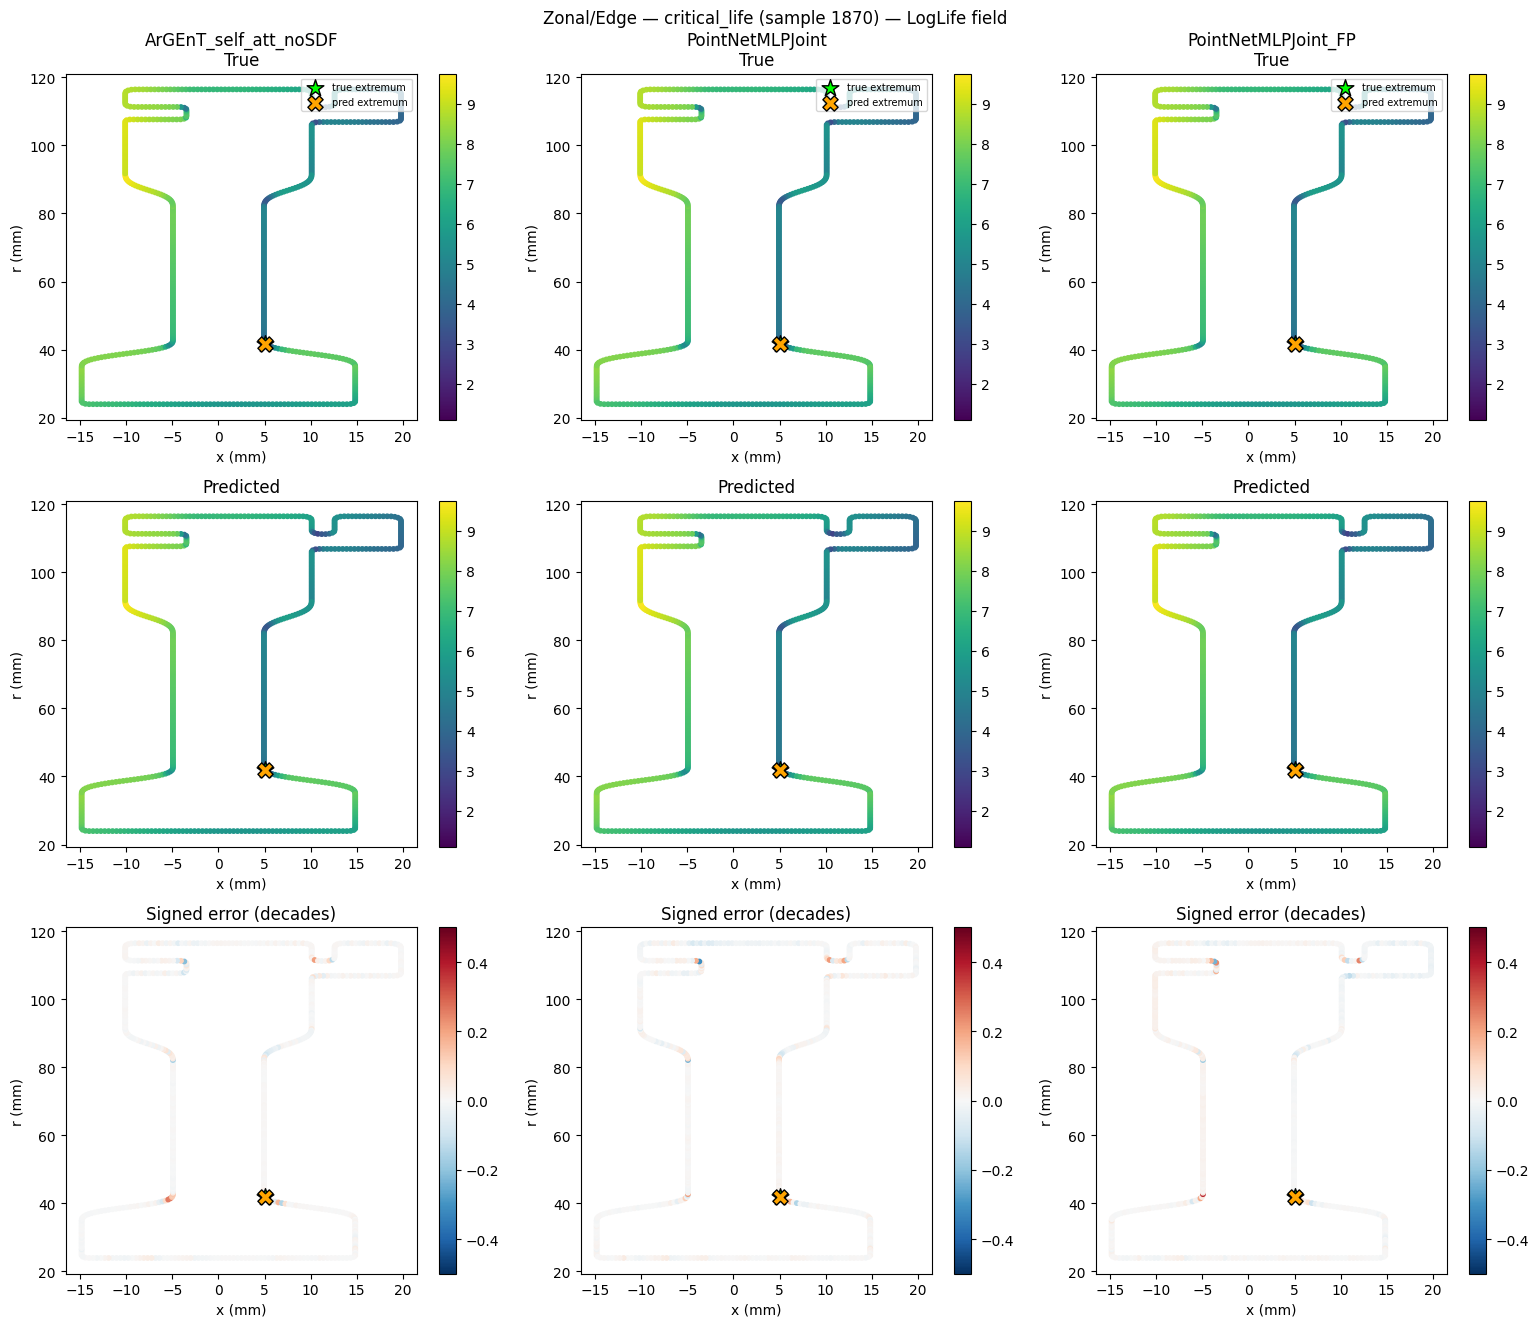

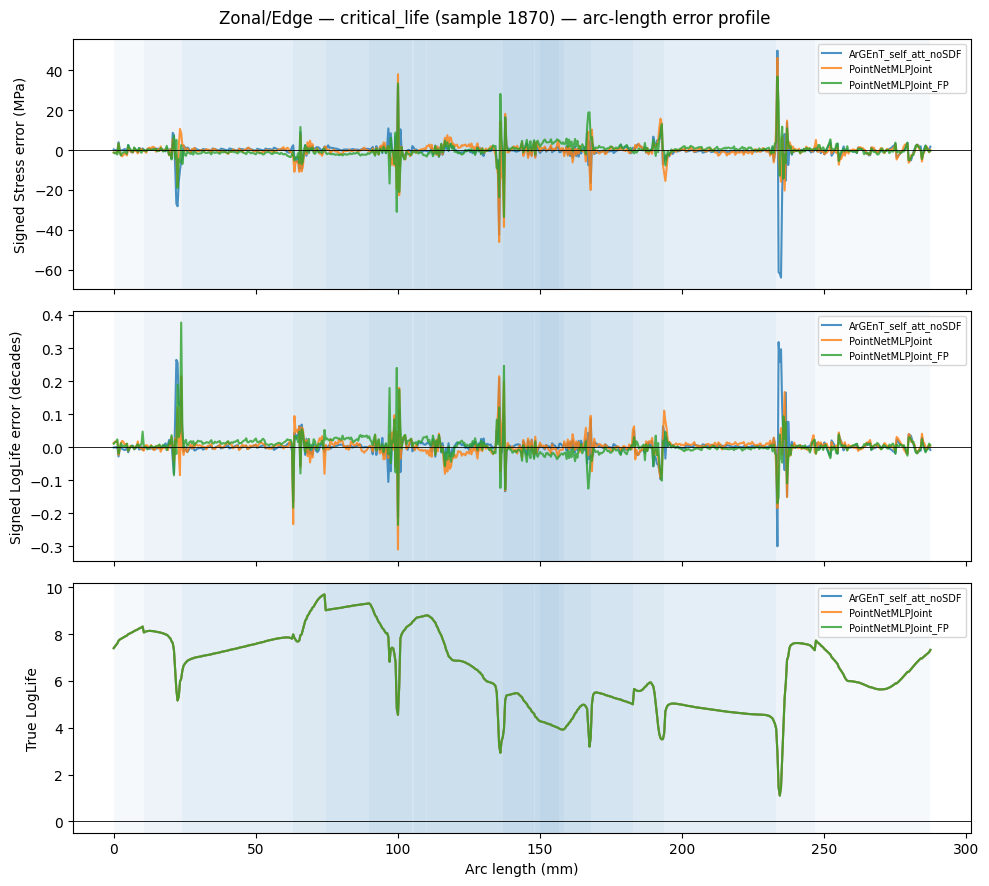

#### model_disagreement — sample_id=3973

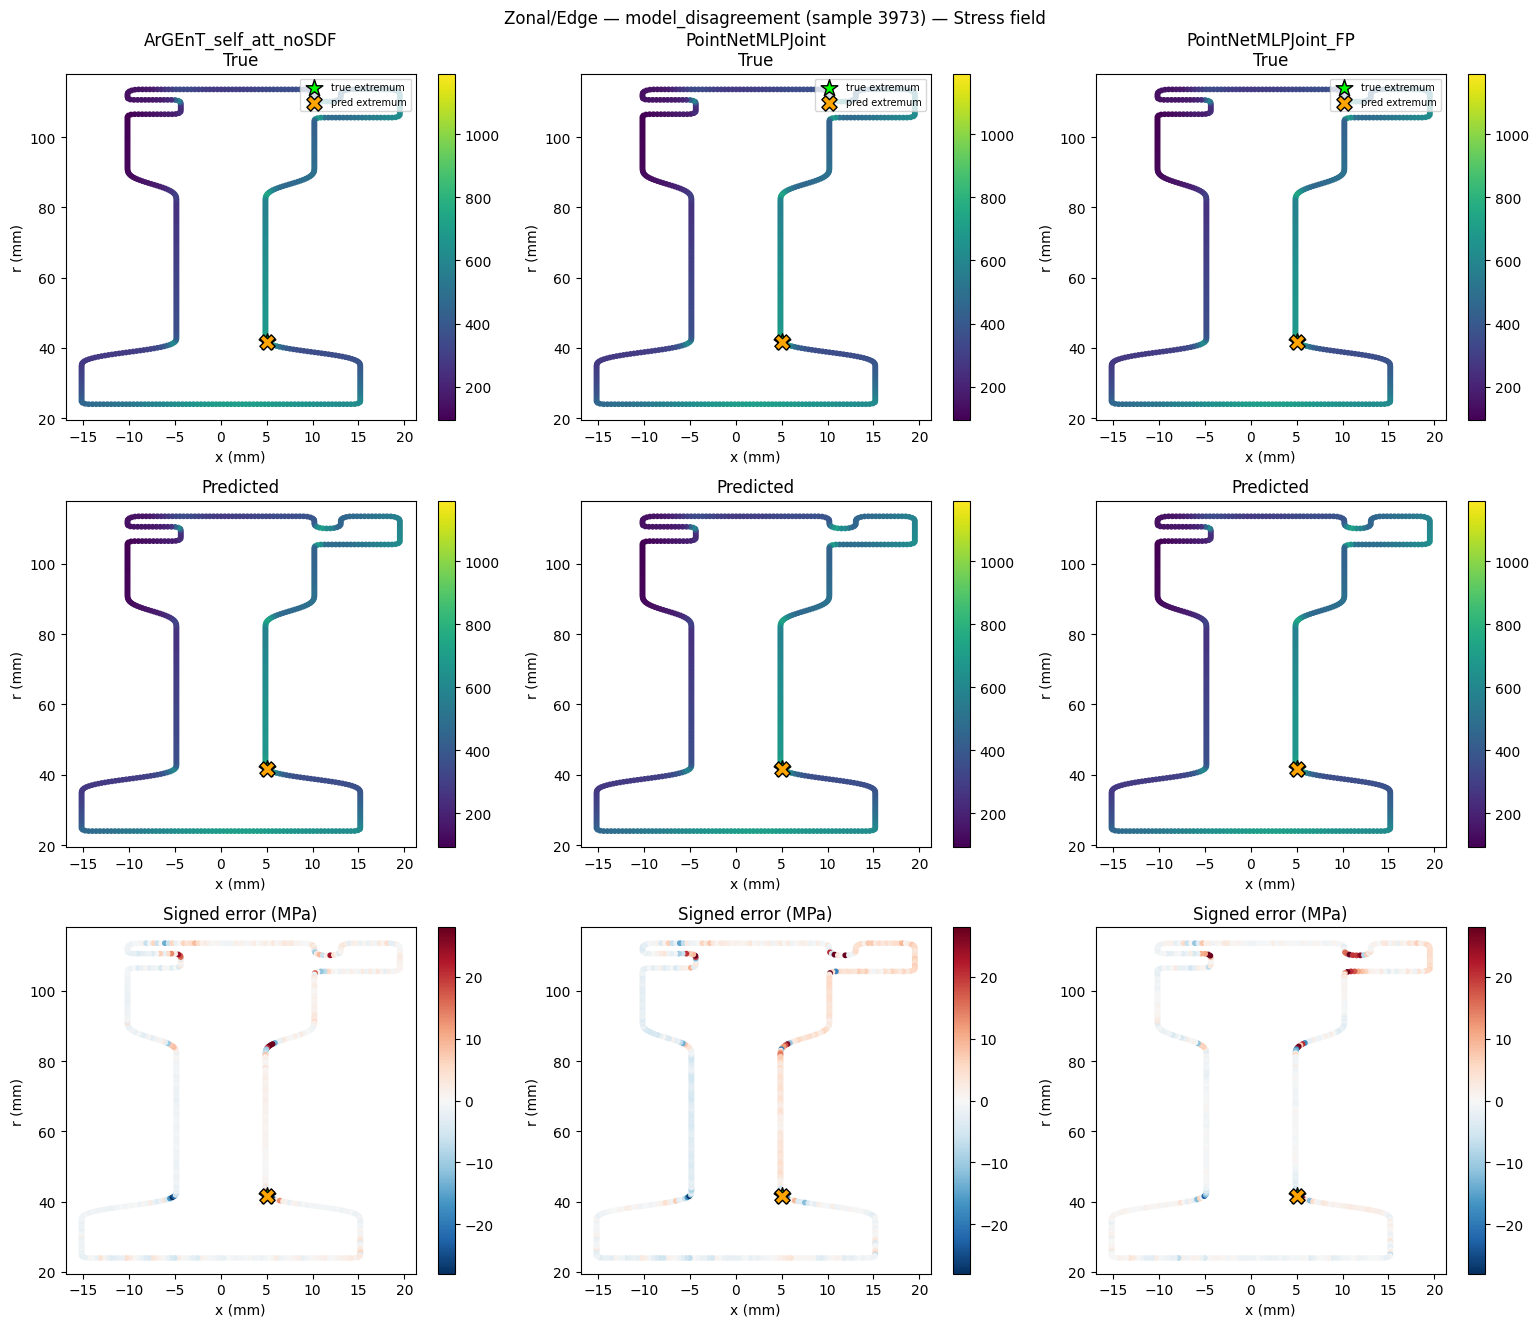

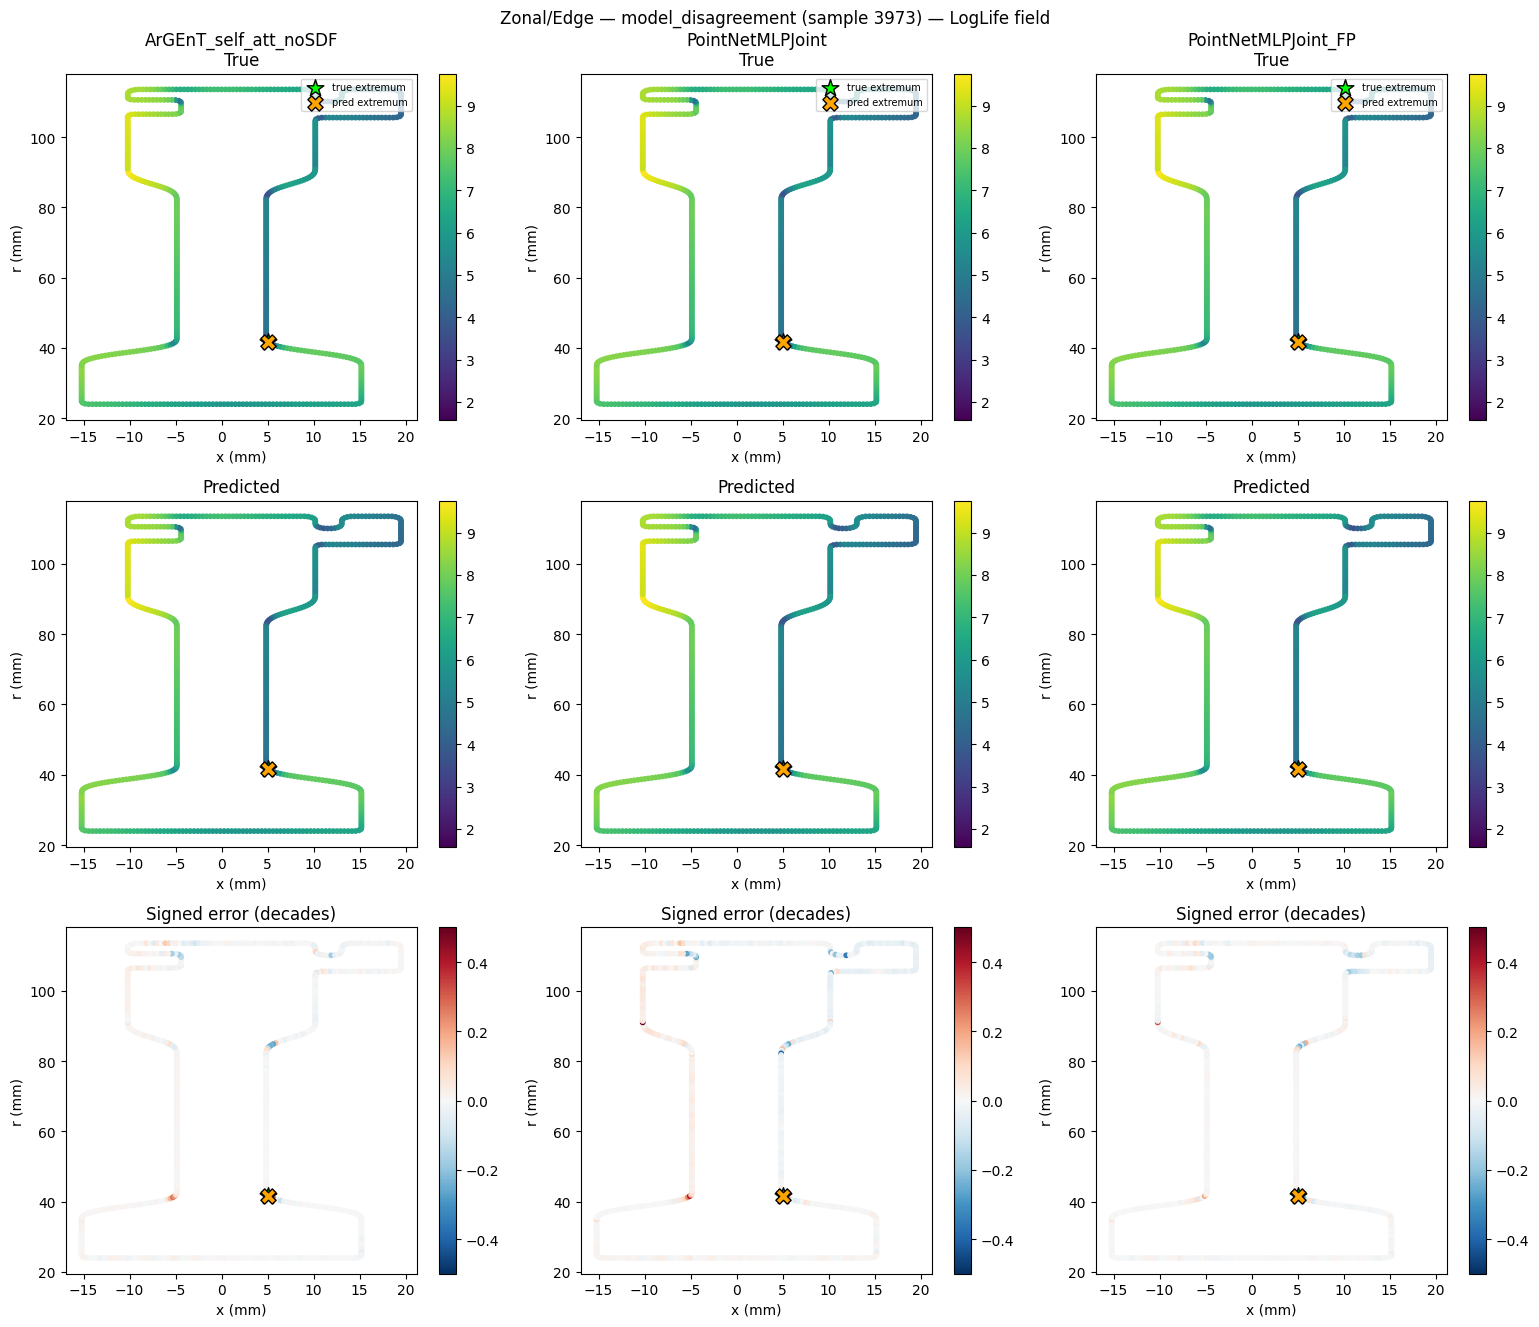

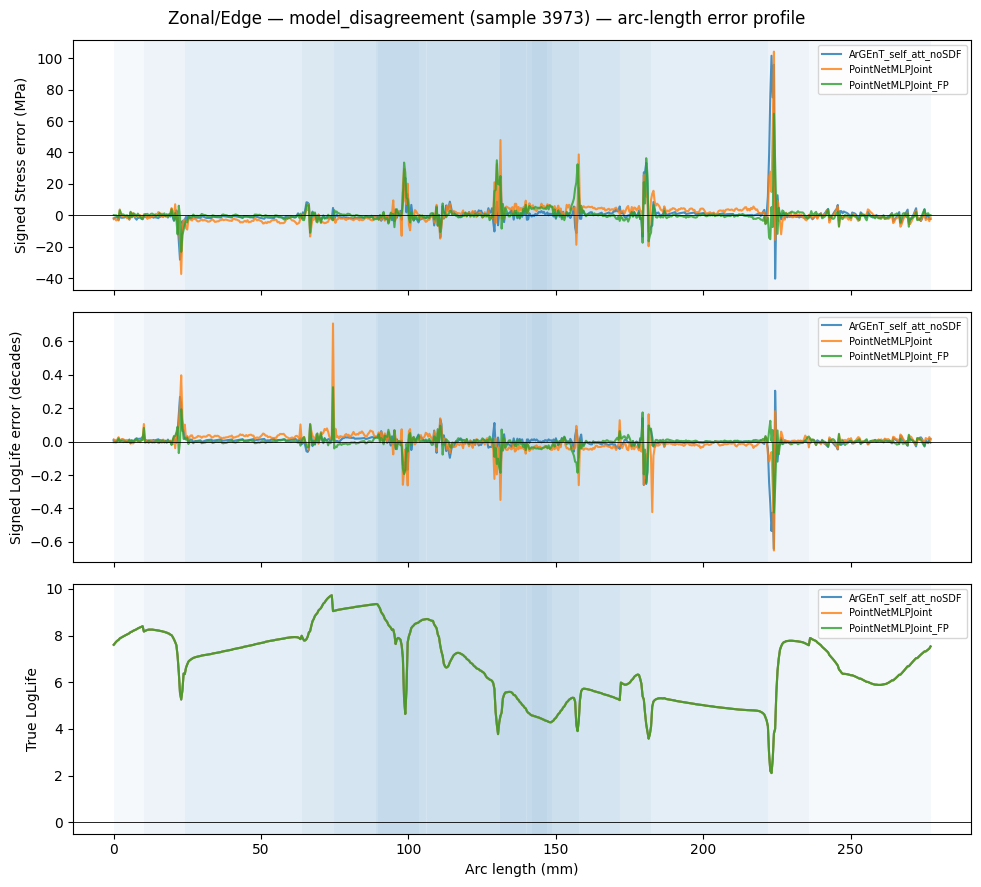

In [46]:
FIGURE_FAMILIES = [f for f in ['ArGEnT_self_att_noSDF', 'PointNetMLPJoint', 'PointNetMLPJoint_FP'] if f in set(principal_geom['model_family'])] if not principal_geom.empty else []

for case_name, sid in representative_ids.items():
    if sid is None:
        continue
    nodes_by_model: Dict[str, pd.DataFrame] = {}
    for fam in FIGURE_FAMILIES:
        d = node_results_df[
            (node_results_df['regime'] == PRINCIPAL_REGIME) & (node_results_df['ablation'] == PRINCIPAL_ABLATION)
            & (node_results_df['model_family'] == fam) & (node_results_df['sample_id'] == sid)
        ]
        if not d.empty:
            nodes_by_model[fam] = d
    if len(nodes_by_model) < 2:
        display(Markdown(f'**{case_name} (sample_id={sid}): fewer than 2 models available — figure skipped.**'))
        continue

    display(Markdown(f'#### {case_name} — sample_id={sid}'))

    eh.plot_field_comparison(
        nodes_by_model, 'true_stress', 'pred_stress', 'MPa',
        f'{PRINCIPAL_REGIME}/{PRINCIPAL_ABLATION} — {case_name} (sample {sid}) — Stress field',
        fixed_error_limit=None, mark_extrema='max',
        out_dir=FIGURES_DIR, filename=f'stress_field_{case_name}_{sid}',
    )
    plt.show()

    eh.plot_field_comparison(
        nodes_by_model, 'true_loglife', 'pred_loglife', 'decades',
        f'{PRINCIPAL_REGIME}/{PRINCIPAL_ABLATION} — {case_name} (sample {sid}) — LogLife field',
        fixed_error_limit=0.5, mark_extrema='min',
        out_dir=FIGURES_DIR, filename=f'loglife_field_{case_name}_{sid}',
    )
    plt.show()

    if any(nodes_by_model[m]['arc_length_mm'].notna().any() for m in nodes_by_model):
        eh.plot_arc_length_error(
            nodes_by_model, f'{PRINCIPAL_REGIME}/{PRINCIPAL_ABLATION} — {case_name} (sample {sid}) — arc-length error profile',
            out_dir=FIGURES_DIR, filename=f'arc_length_error_{case_name}_{sid}',
        )
        plt.show()
    else:
        display(Markdown('_No `arc_length_mm` available for this ablation — arc-length figure skipped._'))


## Fair comparison conclusion (FP vs. GC-PointNet vs. ArGEnT)

Comparison hierarchy (never inverted): (1) `GC-PointNet` vs `LC-PointNet` isolates
the effect of feature propagation; (2) the better PointNet-family variant vs `Adapted ArGEnT-inspired attention operator`
isolates the architecture effect. A pooled R² difference in the fourth decimal place is
**never** treated as evidence on its own.



In [47]:
def compare_metric(better_is_lower_a, better_is_lower_b, name):
    if better_is_lower_a is None or better_is_lower_b is None or np.isnan(better_is_lower_a) or np.isnan(better_is_lower_b):
        return f"{name}: not available"
    if np.isclose(better_is_lower_a, better_is_lower_b, rtol=1e-3):
        return f"{name}: no material difference (FP={better_is_lower_a:.4f} vs PointNetMLPJoint={better_is_lower_b:.4f})"
    winner = 'FP' if better_is_lower_a < better_is_lower_b else 'PointNetMLPJoint'
    return f"{name}: {winner} lower ({'FP' if winner=='FP' else 'PN'}={min(better_is_lower_a, better_is_lower_b):.4f} vs {max(better_is_lower_a, better_is_lower_b):.4f})"


conclusion_lines: List[str] = [f"**Provenance**: `{PROVENANCE_LABEL}` — treat all statements below accordingly."]

pn_fp = metrics_long[
    (metrics_long['regime'] == PRINCIPAL_REGIME) & (metrics_long['ablation'] == PRINCIPAL_ABLATION)
    & (metrics_long['model_family'].isin(['PointNetMLPJoint', 'PointNetMLPJoint_FP'])) & (metrics_long['target'] == 'LogLife')
] if not metrics_long.empty else pd.DataFrame()

verdicts: List[str] = []
if pn_fp.empty or pn_fp['model_family'].nunique() < 2:
    conclusion_lines.append("- Pooled LogLife: FP and/or PointNetMLPJoint not both evaluated — cannot compare.")
else:
    a = pn_fp[pn_fp['model_family'] == 'PointNetMLPJoint_FP']['MAE'].iloc[0]
    b = pn_fp[pn_fp['model_family'] == 'PointNetMLPJoint']['MAE'].iloc[0]
    line = compare_metric(a, b, 'Pooled LogLife MAE')
    conclusion_lines.append(f"- {line}")
    verdicts.append('FP' in line and 'FP lower' in line)

low_life_bins = bin_metrics_df[
    (bin_metrics_df['regime'] == PRINCIPAL_REGIME) & (bin_metrics_df['ablation'] == PRINCIPAL_ABLATION)
    & (bin_metrics_df['bin'] == 'LogLife<2') & (bin_metrics_df['model_family'].isin(['PointNetMLPJoint', 'PointNetMLPJoint_FP']))
] if not bin_metrics_df.empty else pd.DataFrame()
if low_life_bins.empty or low_life_bins['model_family'].nunique() < 2:
    conclusion_lines.append("- Low-life (LogLife<2) MAE: not comparable (insufficient data or unstable bin).")
elif low_life_bins['unstable'].any():
    conclusion_lines.append("- Low-life (LogLife<2) MAE: bin marked UNSTABLE (too few nodes) — no claim made.")
else:
    a = low_life_bins[low_life_bins['model_family'] == 'PointNetMLPJoint_FP']['MAE'].iloc[0]
    b = low_life_bins[low_life_bins['model_family'] == 'PointNetMLPJoint']['MAE'].iloc[0]
    line = compare_metric(a, b, 'Low-life (LogLife<2) MAE')
    conclusion_lines.append(f"- {line}")
    verdicts.append('FP lower' in line)

lt_zone = zone_metrics_df[
    (zone_metrics_df['regime'] == PRINCIPAL_REGIME) & (zone_metrics_df['ablation'] == PRINCIPAL_ABLATION)
    & (zone_metrics_df['subzone_name'] == 'lower_transition') & (zone_metrics_df['model_family'].isin(['PointNetMLPJoint', 'PointNetMLPJoint_FP']))
] if not zone_metrics_df.empty else pd.DataFrame()
if lt_zone.empty or lt_zone['model_family'].nunique() < 2 or (lt_zone['status'] == 'missing').any():
    conclusion_lines.append("- Lower-transition subzone LogLife MAE: not comparable (missing/insufficient data).")
else:
    a = lt_zone[lt_zone['model_family'] == 'PointNetMLPJoint_FP']['MAE'].iloc[0]
    b = lt_zone[lt_zone['model_family'] == 'PointNetMLPJoint']['MAE'].iloc[0]
    line = compare_metric(a, b, 'Lower-transition subzone LogLife MAE')
    conclusion_lines.append(f"- {line}")
    verdicts.append('FP lower' in line)

if not paired_df.empty:
    median_diff = float(paired_df['argent_minus_fp'].median())
    frac_fp_better_vs_argent = float((paired_df['argent_minus_fp'] > 0).mean())
    conclusion_lines.append(
        f"- Per-geometry min-LogLife error, ArGEnT vs FP: median(argent_minus_fp)={median_diff:.4f} "
        f"(positive => FP better); FP has lower abs error than ArGEnT in {frac_fp_better_vs_argent:.0%} of shared geometries."
    )
else:
    conclusion_lines.append("- Per-geometry min-LogLife (ArGEnT vs FP) comparison: not available.")

if len(set(verdicts)) > 1:
    conclusion_lines.append("\n**⚠️ Conclusions differ by metric** — FP does not uniformly help or hurt across pooled, low-life, and subzone metrics. Do not summarize with a single number.")
elif verdicts and all(verdicts):
    conclusion_lines.append("\n**FP consistently improves the metrics compared above** for this regime/ablation, subject to the provenance caveat.")
elif verdicts and not any(verdicts):
    conclusion_lines.append("\n**FP does not improve the metrics compared above** for this regime/ablation, subject to the provenance caveat.")

display(Markdown("\n".join(conclusion_lines)))
eh.save_json({'lines': conclusion_lines}, OUTPUT_DIR, 'fp_vs_pointnet_conclusion')


**Provenance**: `validation-split evaluation` — treat all statements below accordingly.
- Pooled LogLife MAE: FP lower (FP=0.0173 vs 0.0197)
- Low-life (LogLife<2) MAE: FP lower (FP=0.0964 vs 0.1167)
- Lower-transition subzone LogLife MAE: FP lower (FP=0.0275 vs 0.0321)
- Per-geometry min-LogLife error, ArGEnT vs FP: median(argent_minus_fp)=0.1673 (positive => FP better); FP has lower abs error than ArGEnT in 90% of shared geometries.

**FP consistently improves the metrics compared above** for this regime/ablation, subject to the provenance caveat.